In [1]:
from model_solver import *
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import json

import matplotlib.ticker as mtick
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

import matplotlib as mpl

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


##################################################################
###################  Hyperparameters here  #####################
##################################################################

calib=0
savefig=1

##################################################################
###################  UNCONSTRAINED RAW LAND  #####################
##################################################################

taxes_calib = {         # benchmark tax to calibrate on
    'tau_s_inv':        0.0,
    'tau_S_inv':        0.0,
    'tau_K_inv':        0.0,
    'tau_K':            0.011,
    'tau_l_surface':    0.0,
    'tau_l_value':      0.0,
    'tau_L_surface':    0.0,
    'tau_L_value':      0.0,
    'tau_LR_surface':   0.0,
    'tau_LR_value':     0.0,
    'tau_LDV_sale':     0.0,
    'tau_LR_sale':      0.0,
    'tau_H':            0.0,
    'tau_HI':           0.0,
    'tau_D_K':          0.0,
    'tau_D_S':          0.0,
    'tau_D_s':          0.0,
    'tau_D_H':          0.0,
    'tau_D_h':          0.0,
    'tau_D_L':          0.0,
    'tau_D_l':          0.0,
    'tau_D_LR':         0.0,
    'tau_inher_K':      0.0,
    'tau_inher_S':      0.0,
    'tau_inher_s':      0.0,
    'tau_inher_H':      0.0,
    'tau_inher_h':      0.0,
    'tau_inher_L':      0.0,
    'tau_inher_l':      0.0,
    'tau_inher_LR':     0.0,
}

# the all tax set to zero case
taxes_eq0 = taxes_calib.copy()
taxes_eq0['tau_K_inv'] = 0.0
taxes_eq0['tau_K'] = 0.0

# fixed parameters
params_exog = {
    "aleph":    0.01, 
    "n":        0.01, 
    "beta":     0.95, 
    "omega":    0.6956521739130435, # 0.6956521739130435, 
    "varrho":   0.043478260869565216, 
    "gamma_C":  0.25, 
    "gamma_R":  0.25, 
    "delta_K":  0.09, 
    "delta_S":  0.015, 
    "alpha_CH": 0.75, # 0.76
    "sigma":    2.5, 
    "a_L":      0.5, 
    "alpha_K":  0.3333333333333333, 
    "A":        1, 
    "rho_h":    0.05, 
    "rho_H":    0.05,
}

params_endog0 = {
    "cost_L1": 0, 
    "cost_L2":   46.25,        # 0.62905859976161, 
    "R_R":      0.178,       #0.12658109235265091, 
    "Lbar":     2
}

init_guess = {              # initial guess of the x vector
    "c": 0.7501029863335733, 
    "C": 1.2273556513042563, 
    "C_R": 1.7454592520616932, 
    "s": 1.228191424105679, 
    "S": 2.888839715397431,
    "l": 0.5170629868792102, 
    "L": 1.2161883420952917, 
    "LR": 6.135219433586456, 
    # "K" : 4.513374433497551
}


# ----------------------------------------------------------------
# ------------------------- Calibration --------------------------
# ----------------------------------------------------------------

# set targets
targets = {
    'LR_GDP_ratio'  :   (1160/2400),    # 0.5
    'dev_GDP_ratio' :   (4109/2400),    # 0.46
    'real_estate_GDP_ratio' :  (8918/2400),     # 3.715
    'K_Y_ratio' :           (2), 
    'pLDV_pLR_ratio' : ((90/10)/0.282),    # (0.282/(95/5))    (2.27/2)
    'LDV_LR_ratio':      (10/90)
}


if calib==1:
    print('\n============ Calibration - unconstrained ============')

    # calibration
    sol_calib, params_endog1 = solve_ss(
        params_exog, params_endog0, taxes_calib, init_guess, calib=1, targets=targets
        )


    # show target match
    print('\n------------- Targets -------------')

    for targ in targets.keys():
        print(f'{targ} = {sol_calib[targ]}; Target = {targets[targ]}')

    print('\n------------- Calibrated parameters -------------')
    for par in params_endog1.keys():
        print(f'{par} = {params_endog1[par]}')

else:

    # use preselected value instead
    params_endog1 = {
        "cost_L1": 0.5, # 0.5,
        "cost_L2": (0.62905859976161 - 0.5) / (1.36 * 0.01), #  (0.62905859976161 - 0.5) / (1.36 * 0.01),  # 0.62905859976161, 
        "R_R": 0.178,  # 0.12658109235265091, 
        "Lbar": 2
    }


# Combine params_exog and params_endog1 into a single dictionary
params_combined = {**params_exog, **params_endog1}
params_combined['n'] = 0.01
params_combined['cost_L1'] = 0.5
params_combined['cost_L2'] = (0.62905859976161 - 0.5) / (1.36 * 0.01) # (0.62905859976161 - 0.5) / (1.36 * 0.01)

# Save the combined dictionary to a JSON file
with open('ParamDynamics.json', 'w') as file:
    json.dump(params_combined, file)


sol_calib = solve_ss(params_exog, params_endog1, taxes_calib, init_guess)

# ----------------------------------------------------------------
# ----------- No tax benchmark with calib params -----------------
# ----------------------------------------------------------------

sol_taxeq0 = solve_ss(params_exog, params_endog1, taxes_eq0, init_guess)

NatIncome_taxeq0 = sol_taxeq0['NatIncome_prod']
welfare_taxeq0   = sol_taxeq0['welfare']

print('\n------------- Print calib and no tax benchmark -------------')

# print a table of key variables and target
create_table(sol_calib, sol_taxeq0, targets)
print(latex_table(sol_calib, sol_taxeq0, targets))





# store outcomes
with open('ParamEndog_uncons_calib.json', 'w') as file:
    json.dump(params_endog1, file)

with open('sol_uncons_calib.json', 'w') as js:
    json.dump(sol_calib, js)

with open('sol_uncons_taxeq0.json', 'w') as js:
    json.dump(sol_taxeq0, js)
    


# ----------------------------------------------------------------
# ------------ Steady state tax comparative statics --------------
# ----------------------------------------------------------------
print('\n============ Steady state tax effects ============')

# all tax schemes that we want to demonstrate
# direct taxes
land_tax = [
    ('Raw land surface',         ['tau_LR_surface']),
    ('Raw land value',           ['tau_LR_value']),
    ('Uniform: raw and dev. land surface', ['tau_L_surface', 'tau_l_surface', 
                                            'tau_LR_surface', 'tau_LR_0_surface']),
    ('Uniform rate: raw and dev. land value',   ['tau_L_value', 'tau_l_value', 
                                            'tau_LR_value', 'tau_LR_0_value']),
    ('Uniform value: raw and dev. land value',   ['tau_L_value', 'tau_l_value', 
                                            'tau_LR_value', 'tau_LR_0_value']),

    ('Home-owner land surface',  ['tau_L_surface']),
    ('Home-owner land value',    ['tau_L_value']),
    ('Dev. land surface',   ['tau_L_surface', 'tau_l_surface']),
    ('Dev. land value',     ['tau_L_value', 'tau_l_value']),

    ('Rental land surface',      ['tau_l_surface']),
    ('Rental land value',        ['tau_l_value']),

    ('Total land purchase by capitalists',     ['tau_LDV_sale']),
    ('Total land sale by rentiers',            ['tau_LR_sale']),
]

housing_tax = [
    ('Rents',                ['tau_H']),
    ('Imputed rents',        ['tau_HI']),
    ('Uniform: rents and imputed rents',      ['tau_H', 'tau_HI']),
    ('Housing price', ['tau_HI']),
    ('Rental housing price', ['tau_H']),
]

KSs_tax = [
    ('Capital inv.',     ['tau_K_inv']),
    ('Capital stock and return',   ['tau_K']),

    ('Home-owner struct. inv.',     ['tau_S_inv']),
    ('Rental struct. inv.',             ['tau_s_inv']),
    ('Uniform: rental and home-owner struct. inv.', ['tau_s_inv', 'tau_S_inv']),
]

# tax on inheritence - same as taxing accidental bequest
land_tax_DI = [
    ('DI_Home-owner land',    ['tau_inher_L']),
    ('DI_Rental land',        ['tau_inher_l']),
    ('DI_Dev. land',    ['tau_inher_L', 'tau_inher_l']),

    ('DI_Raw land',           ['tau_inher_LR']),
    ('DI_Uniform: raw and dev. land', ['tau_inher_L', 'tau_inher_l', 'tau_inher_LR'])
]

housing_tax_DI = [
    ('DI_Home-owner housing',  ['tau_inher_H']),
    ('DI_Rental housing',      ['tau_inher_h']),
    ('DI_Uniform: rental and home-owner', ['tau_inher_H', 'tau_inher_h'])
]

KSs_tax_DI = [
    ('DI_Capital',              ['tau_inher_K']),
    
    ('DI_Home-owner struct.',   ['tau_inher_S']),
    ('DI_Rental struct.',       ['tau_inher_s']),

    ('DI_Uniform: rental and home-owner struct.',   ['tau_inher_S', 'tau_inher_s']),
]

all_tax = land_tax + housing_tax + KSs_tax + land_tax_DI + housing_tax_DI + KSs_tax_DI




# ------------ simulate the steady state tax change -------------
print('\n------------- Simulate all taxes -------------')
all_sol = dict()

# start and end tax rate
tau_start = 0
tau_end   = 1
num_step  = 500

for tax_name, taxes in all_tax:
    print(f'Progress: simulating tax on {tax_name}')
    
    # simulate comparative statics
    if tax_name in [
        # 'Capital stock and return',         # brentq does not work
        'Total land sale by rentiers'       #  tau_LR_sale = 1 => division by 0 in computing p_R
            ]:
        a = tau_start
        b = tau_end - 1e-2
    elif tax_name in ['Capital stock and return']:
        a = 0 # 0.011
        b = tau_end - 1e-2
    else:
        a = tau_start
        b = tau_end
    
    tax_dict = dict.fromkeys(taxes, np.linspace(a, b, num_step))
    
    if tax_name in ['Rental housing price', 'Housing price']:
        disfac = 1/(1 + params_exog['n'] - params_exog['beta'])
        tax_dict = dict.fromkeys(taxes, np.linspace(a, b, num_step) * disfac)
    
    if tax_name != 'Uniform value: raw and dev. land value':
        df = comp_stat_tax(params_exog, params_endog1, taxes_eq0, tax_dict, sol_taxeq0)   # taxes_calib
    
    else:
        
        # R_R = params_endog1['R_R']
        # cost_L = params_endog1['cost_L']
        # beta = params_exog['beta']
        # n    = params_exog['n']
        
        tau_L_value = np.linspace(0.0, 0.18,  100)

        tax_dict = {
            'tau_L_value': tau_L_value,
            'tau_l_value': tau_L_value
        }
    
        df = comp_stat_tax(params_exog, params_endog1,   # taxes are uniform
                        taxes_eq0, tax_dict, sol_taxeq0, uniformval=1)  # taxes_calib

        

    
    # compute welfare change and nat income transfer relative to Laissez faire economy
    df['welfare %'] = (df['welfare'] - welfare_taxeq0)/np.abs(welfare_taxeq0)
    df['transfer %'] = df['T_total']/NatIncome_taxeq0
    
    all_sol[tax_name] = df

# store solutions in excel spreadsheets
for tax_name in all_sol.keys():
    df = all_sol[tax_name]
    df.to_excel(f'comparative_statics_all_taxes_uncons/{tax_name}.xlsx')




------------- Print calib and no tax benchmark -------------
+-----------------------------+-----------------------+----------------------+----------------------+---------------------+
|             Name            |         Symbol        |      Calibrated      |    Laissez faire     |        Target       |
+-----------------------------+-----------------------+----------------------+----------------------+---------------------+
|       Capitalist cons.      |           C           |  1.2699841269904366  |  1.3003434189367284  |          -          |
|  Worker cons. (per worker)  |           c           |  0.736175539955531   |  0.7376318877553941  |          -          |
| Rentier cons. (per rentier) |          C_R          |  3.487933082293029   |  3.4082347572476257  |          -          |
|       Home-owner land       |           L           |  0.9720324087872624  |  0.9946360833347274  |          -          |
|         Rental land         |           l           | 0.391972945873

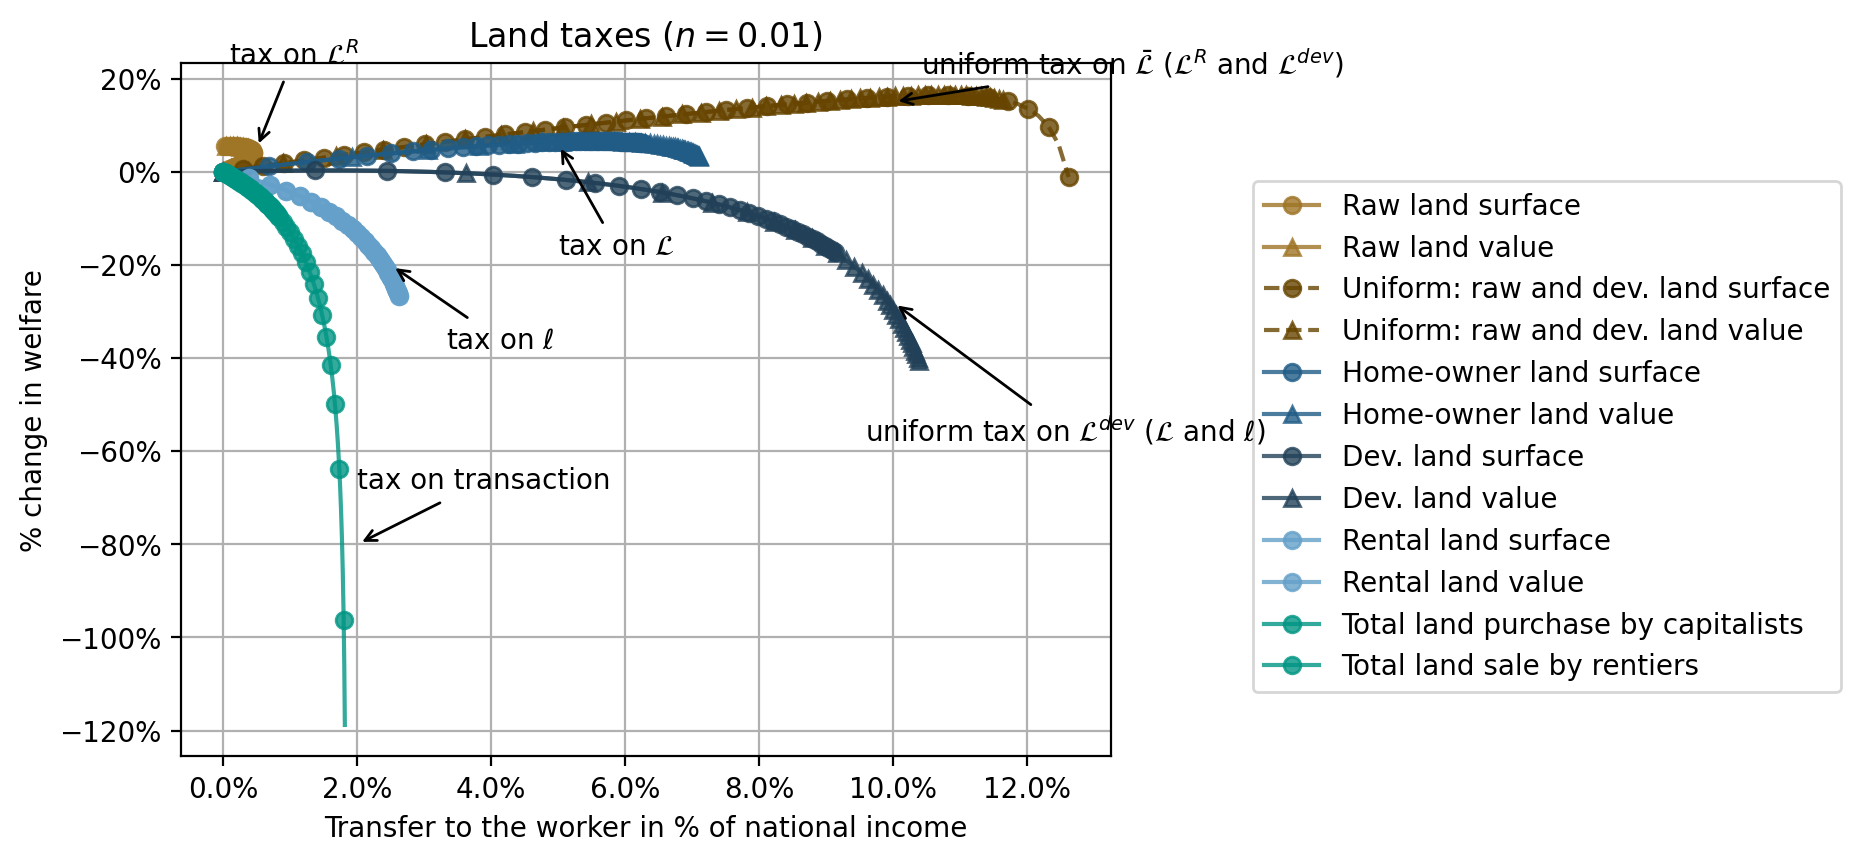

In [2]:


# ----------------------------------------------------------------
# --------------------------- Plots ------------------------------
# ----------------------------------------------------------------

# ----------------------- Figure 1: taxes on land  ------------------------
# (when taxes are pushed to the possible limit)

# retreive all land taxes
df_LR_surface   = all_sol['Raw land surface'].query('sol_flag==0')
df_LR_value     = all_sol['Raw land value'].query('sol_flag==0')
df_LDV_surface  = all_sol['Dev. land surface'].query('sol_flag==0')
df_LDV_value    = all_sol['Dev. land value'].query('sol_flag==0')
df_L_surface    = all_sol['Home-owner land surface'].query('sol_flag==0')
df_L_value      = all_sol['Home-owner land value'].query('sol_flag==0')
df_l_surface    = all_sol['Rental land surface'].query('sol_flag==0')
df_l_value      = all_sol['Rental land value'].query('sol_flag==0')
df_uniformL_surface     = all_sol['Uniform: raw and dev. land surface'].query('sol_flag==0')
# df_uniformLrate_value       = all_sol['Uniform rate: raw and dev. land value'].query('sol_flag==0')
df_uniformLvalue_value       = all_sol['Uniform value: raw and dev. land value'].query('sol_flag==0')
df_land_sale            = all_sol['Total land sale by rentiers'].query('sol_flag==0')
df_land_purchase        = all_sol['Total land purchase by capitalists'].query('sol_flag==0')

# plot
fig0, ax0 = plt.subplots(1,1, figsize=[6,4.5],dpi=200)


ax0.plot(df_LR_surface['transfer %'], df_LR_surface['welfare %'], linestyle='-', marker='o', color='#9F7526', 
         label='Raw land surface', alpha=0.8, markevery=1)
ax0.plot(df_LR_value['transfer %'], df_LR_value['welfare %'], linestyle='-', marker='^', color='#9F7526', 
         label='Raw land value', alpha=0.8, markevery=1)

ax0.plot(df_uniformL_surface['transfer %'], df_uniformL_surface['welfare %'], linestyle='--', marker='o', color='#674500', 
         label='Uniform: raw and dev. land surface', alpha=0.8, markevery=2)
# ax0.plot(df_uniformLrate_value['transfer %'], df_uniformLrate_value['welfare %'], linestyle='--', marker='^', color='#674500', 
#          label='Uniform rate: raw and dev. land value',alpha=0.8, markevery=10)
ax0.plot(df_uniformLvalue_value['transfer %'], df_uniformLvalue_value['welfare %'], linestyle='--', marker='^', color='#674500', 
         label='Uniform: raw and dev. land value',alpha=0.8, markevery=2)

ax0.plot(df_L_surface['transfer %'], df_L_surface['welfare %'], linestyle='-', marker='o', color='#205c86', 
         label='Home-owner land surface', alpha=0.8, markevery=10)
ax0.plot(df_L_value['transfer %'], df_L_value['welfare %'], linestyle='-', marker='^', color='#205c86', 
         label='Home-owner land value', alpha=0.8, markevery=10)

ax0.plot(df_LDV_surface['transfer %'], df_LDV_surface['welfare %'], linestyle='-', marker='o', color='#224158', 
         label='Dev. land surface', alpha=0.8, markevery=15)
ax0.plot(df_LDV_value['transfer %'], df_LDV_value['welfare %'], linestyle='-', marker='^', color='#224158', 
         label='Dev. land value', alpha=0.8, markevery=15)

ax0.plot(df_l_surface['transfer %'], df_l_surface['welfare %'], linestyle='-', marker='o', color='#64a0c9', 
         label='Rental land surface', alpha=0.8, markevery=15)
ax0.plot(df_l_surface['transfer %'], df_l_surface['welfare %'], linestyle='-', marker='o', color='#64a0c9', 
         label='Rental land value', alpha=0.8, markevery=15)

ax0.plot(df_land_sale['transfer %'], df_land_sale['welfare %'], linestyle='-', marker='o', color='#009583', 
         label='Total land purchase by capitalists', alpha=0.8, markevery=15)
ax0.plot(df_land_purchase['transfer %'], df_land_purchase['welfare %'], linestyle='-', marker='o', color='#009583', 
         label='Total land sale by rentiers', alpha=0.8, markevery=15)

ax0.set_xlabel('Transfer to the worker in % of national income')
ax0.set_ylabel('% change in welfare')
ax0.set_title(f"Land taxes ($n={params_exog['n']}$)")
ax0.legend(ncol=1, loc='upper right', bbox_to_anchor=(1.8, 0.85))
ax0.grid()
ax0.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax0.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))


ax0.annotate(r'tax on $\mathcal{L}^R$', 
             xy=[0.5/100, 5/100], xycoords='data',
             xytext=[-10, 30], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'uniform tax on $\bar{\mathcal{L}}$ ($\mathcal{L}^R$ and $\mathcal{L}^{dev}$)',
             xy=[10/100, 15/100], xycoords='data',
             xytext=[10, 10], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'uniform tax on $\mathcal{L}^{dev}$ ($\mathcal{L}$ and $\ell$)', 
             xy=[10/100, -28/100], xycoords='data',
             xytext=[-10, -50], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'tax on $\mathcal{L}$', 
             xy=[5/100, 6/100], xycoords='data',
             xytext=[0, -40], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'tax on $\ell$',
            xy=[2.5/100, -20/100], xycoords='data',
             xytext=[20, -30], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'tax on transaction', 
             xy=[2/100, -80/100], xycoords='data',
             xytext=[0, 20], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)

if savefig==1:
    plt.savefig('Figures/Fig1_taxes_on_land.png', bbox_inches='tight')

plt.show()


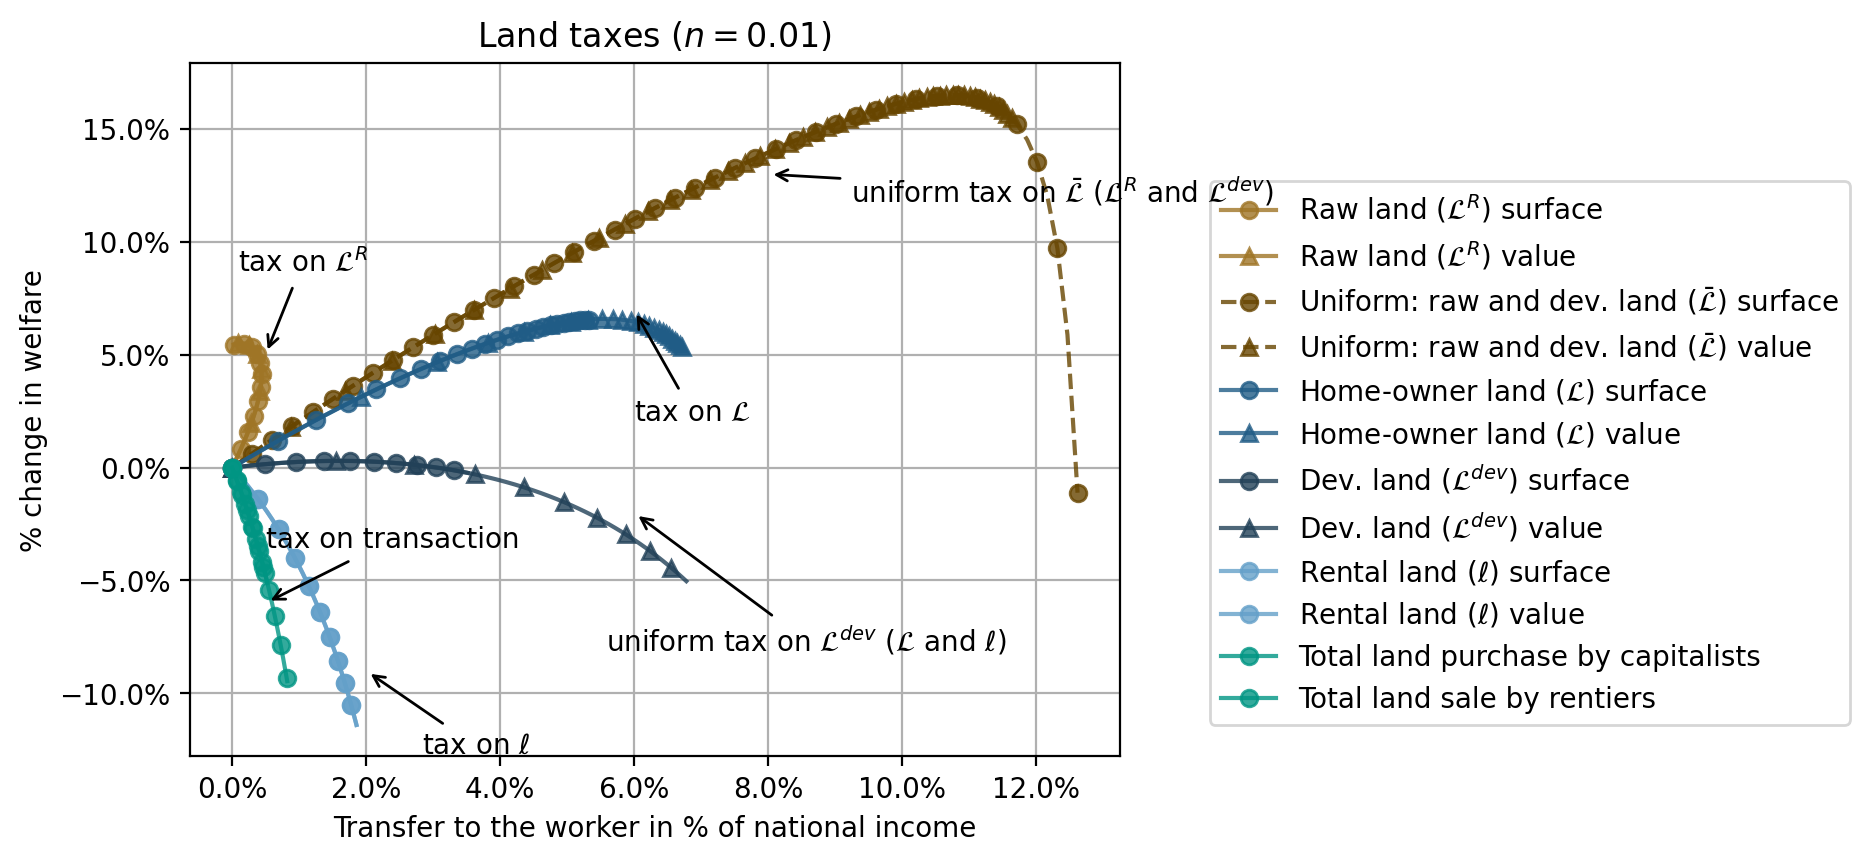

In [3]:

# ----------------------- Figure 2: taxes on land (truncated) ------------------------

# Plot truncated version and put full version in Appendix
df_LR_surface_trunc   = df_LR_surface.query('tau_LR_surface <= 1')
df_LR_value_trunc     = df_LR_value.query('tau_LR_value <= 1')
df_LDV_surface_trunc  = df_LDV_surface.query('tau_L_surface <= 0.1')
df_LDV_value_trunc    = df_LDV_value.query('tau_L_value <= 0.1')
df_L_surface_trunc    = df_L_surface.query('tau_L_surface <= 0.5')
df_L_value_trunc      = df_L_value.query('tau_L_value <= 0.5')
df_l_surface_trunc    = df_l_surface.query('tau_l_surface <= 0.3')
df_l_value_trunc      = df_l_value.query('tau_l_value <= 0.3')
df_uniformL_surface_trunc     = df_uniformL_surface.query('tau_LR_surface <= 0.9')
df_uniformLvalue_value_trunc  = df_uniformLvalue_value.query('tau_LR_value <= 0.9')
df_land_sale_trunc            = df_land_sale.query('tau_LR_sale <= 0.5')
df_land_purchase_trunc        = df_land_purchase.query('tau_LDV_sale <= 0.5')


fig0, ax0 = plt.subplots(1,1, figsize=[6,4.5],dpi=200)


ax0.plot(df_LR_surface_trunc['transfer %'], df_LR_surface_trunc['welfare %'], linestyle='-', marker='o', color='#9F7526', 
         label=r'Raw land ($\mathcal{L}^R$) surface', alpha=0.8, markevery=3)
ax0.plot(df_LR_value_trunc['transfer %'], df_LR_value_trunc['welfare %'], linestyle='-', marker='^', color='#9F7526', 
         label=r'Raw land ($\mathcal{L}^R$) value', alpha=0.8, markevery=3)

ax0.plot(df_uniformL_surface_trunc['transfer %'], df_uniformL_surface_trunc['welfare %'], linestyle='--', marker='o', color='#674500', 
         label=r'Uniform: raw and dev. land ($\bar{\mathcal{L}}$) surface', alpha=0.8, markevery=2)

ax0.plot(df_uniformLvalue_value_trunc['transfer %'], df_uniformLvalue_value_trunc['welfare %'], linestyle='--', marker='^', color='#674500', 
         label=r'Uniform: raw and dev. land ($\bar{\mathcal{L}}$) value',alpha=0.8, markevery=2)

ax0.plot(df_L_surface_trunc['transfer %'], df_L_surface_trunc['welfare %'], linestyle='-', marker='o', color='#205c86', 
         label=r'Home-owner land ($\mathcal{L}$) surface', alpha=0.8, markevery=10)
ax0.plot(df_L_value_trunc['transfer %'], df_L_value_trunc['welfare %'], linestyle='-', marker='^', color='#205c86', 
         label=r'Home-owner land ($\mathcal{L}$) value', alpha=0.8, markevery=10)

ax0.plot(df_LDV_surface_trunc['transfer %'], df_LDV_surface_trunc['welfare %'], linestyle='-', marker='o', color='#224158', 
         label=r'Dev. land ($\mathcal{L}^{dev}$) surface', alpha=0.8, markevery=5)
ax0.plot(df_LDV_value_trunc['transfer %'], df_LDV_value_trunc['welfare %'], linestyle='-', marker='^', color='#224158', 
         label=r'Dev. land ($\mathcal{L}^{dev}$) value', alpha=0.8, markevery=5)

ax0.plot(df_l_surface_trunc['transfer %'], df_l_surface_trunc['welfare %'], linestyle='-', marker='o', color='#64a0c9', 
         label=r'Rental land ($\ell$) surface', alpha=0.8, markevery=15)
ax0.plot(df_l_surface_trunc['transfer %'], df_l_surface_trunc['welfare %'], linestyle='-', marker='o', color='#64a0c9', 
         label=r'Rental land ($\ell$) value', alpha=0.8, markevery=15)

ax0.plot(df_land_sale_trunc['transfer %'], df_land_sale_trunc['welfare %'], linestyle='-', marker='o', color='#009583', 
         label='Total land purchase by capitalists', alpha=0.8, markevery=25)
ax0.plot(df_land_purchase_trunc['transfer %'], df_land_purchase_trunc['welfare %'], linestyle='-', marker='o', color='#009583', 
         label='Total land sale by rentiers', alpha=0.8, markevery=25)

ax0.set_xlabel('Transfer to the worker in % of national income')
ax0.set_ylabel('% change in welfare')
ax0.set_title(f"Land taxes ($n={params_exog['n']}$)")
ax0.legend(ncol=1, loc='upper right', bbox_to_anchor=(1.8, 0.85))
ax0.grid()
ax0.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax0.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))


ax0.annotate(r'tax on $\mathcal{L}^R$', 
             xy=[0.5/100, 5/100], xycoords='data',
             xytext=[-10, 30], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'uniform tax on $\bar{\mathcal{L}}$ ($\mathcal{L}^R$ and $\mathcal{L}^{dev}$)',
             xy=[8/100, 13/100], xycoords='data',
             xytext=[30, -10], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'uniform tax on $\mathcal{L}^{dev}$ ($\mathcal{L}$ and $\ell$)', 
             xy=[6/100, -2/100], xycoords='data',
             xytext=[-10, -50], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'tax on $\mathcal{L}$', 
             xy=[6/100, 7/100], xycoords='data',
             xytext=[0, -40], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'tax on $\ell$',
            xy=[2/100, -9/100], xycoords='data',
             xytext=[20, -30], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'tax on transaction', 
             xy=[0.5/100, -6/100], xycoords='data',
             xytext=[0, 20], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
if savefig==1:
    plt.savefig('Figures/Fig2_taxes_on_land_truncated.png', bbox_inches='tight')
plt.show()



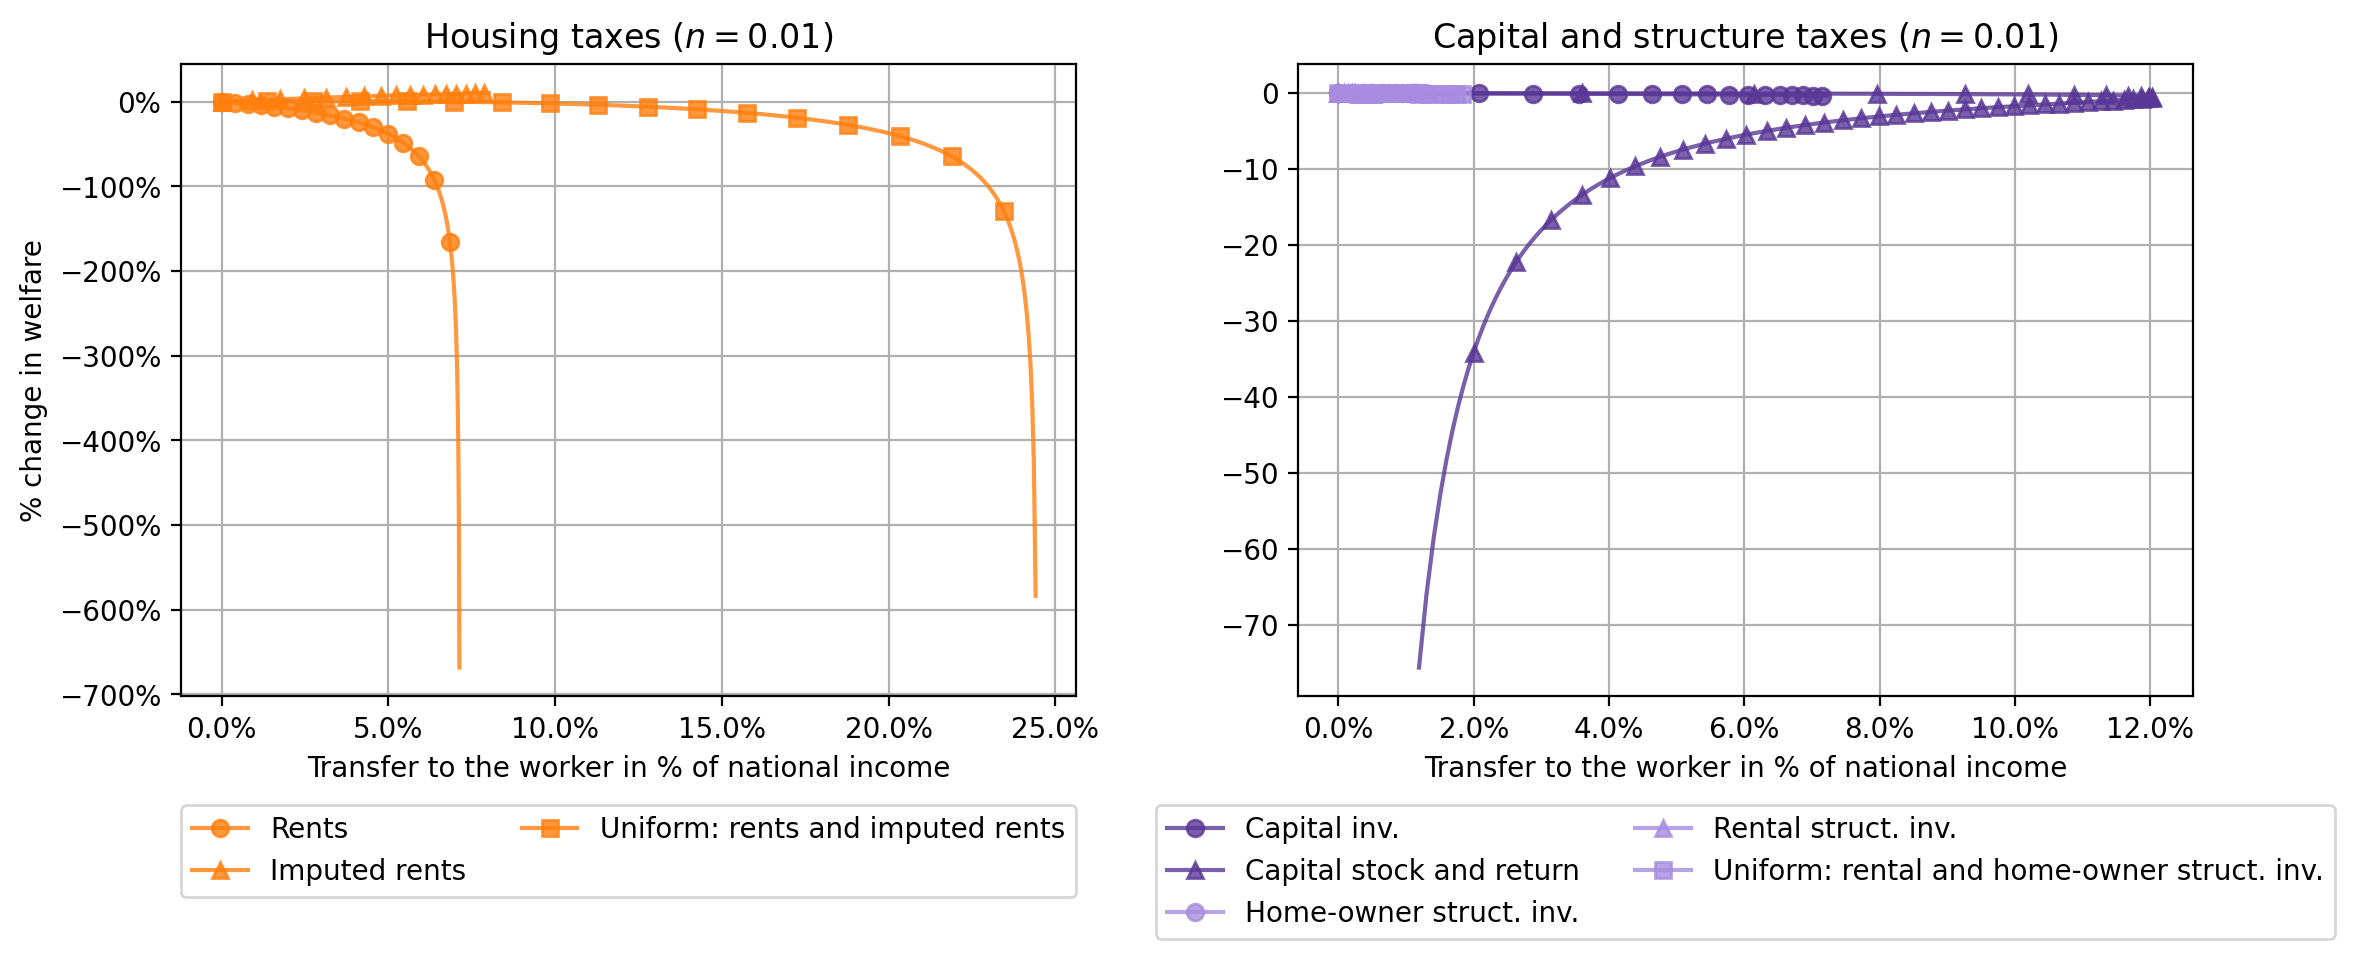

In [4]:

# ----------------------- Figure 3: taxes on housing, capital and structure ------------------------

# retreive all housing, capital, struct taxes
df_h   = all_sol['Rents'].query('sol_flag==0')
df_H     = all_sol['Imputed rents'].query('sol_flag==0')
df_uniformHh  = all_sol['Uniform: rents and imputed rents'].query('sol_flag==0')

df_K_inv    = all_sol['Capital inv.'].query('sol_flag==0')
df_K    = all_sol['Capital stock and return'].query('sol_flag==0')
df_S      = all_sol['Home-owner struct. inv.'].query('sol_flag==0')
df_s    = all_sol['Rental struct. inv.'].query('sol_flag==0')
df_uniformSs      = all_sol['Uniform: rental and home-owner struct. inv.'].query('sol_flag==0')


fig, ax1 = plt.subplots(1,2, figsize=[12,5], dpi=200)
ax1[0].plot(df_h['transfer %'], df_h['welfare %'], linestyle='-', marker='o', color='tab:orange', 
         label='Rents', alpha=0.8, markevery=30)
ax1[0].plot(df_H['transfer %'], df_H['welfare %'], linestyle='-', marker='^', color='tab:orange', 
         label='Imputed rents', alpha=0.8, markevery=30)
ax1[0].plot(df_uniformHh['transfer %'], df_uniformHh['welfare %'], linestyle='-', marker='s', color='tab:orange', 
         label='Uniform: rents and imputed rents', alpha=0.8, markevery=30)

ax1[1].plot(df_K_inv['transfer %'], df_K_inv['welfare %'], linestyle='-', marker='o', color='#593796', 
         label='Capital inv.', alpha=0.8, markevery=30)
ax1[1].plot(df_K['transfer %'], df_K['welfare %'], linestyle='-', marker='^', color='#593796', 
         label='Capital stock and return', alpha=0.8, markevery=10)

ax1[1].plot(df_S['transfer %'], df_S['welfare %'], linestyle='-', marker='o', color='#A78CE0', 
         label='Home-owner struct. inv.', alpha=0.8, markevery=40)
ax1[1].plot(df_s['transfer %'], df_s['welfare %'], linestyle='-', marker='^', color='#A78CE0', 
         label='Rental struct. inv.', alpha=0.8, markevery=40)
ax1[1].plot(df_uniformSs['transfer %'], df_uniformSs['welfare %'], linestyle='-', marker='s', color='#A78CE0', 
         label='Uniform: rental and home-owner struct. inv.', alpha=0.8, markevery=40)

ax1[0].set_xlabel('Transfer to the worker in % of national income')
ax1[0].set_ylabel('% change in welfare')
ax1[0].set_title(f"Housing taxes ($n={params_exog['n']}$)")
ax1[0].legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax1[0].grid()
ax1[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax1[1].set_xlabel('Transfer to the worker in % of national income')
# ax2.set_ylabel('% change in welfare')
ax1[1].set_title(f"Capital and structure taxes ($n={params_exog['n']}$)")
ax1[1].legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax1[1].grid()
ax1[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# ax1[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

fig.tight_layout()

if savefig==1:
    plt.savefig('Figures/Fig3_taxes_on_housing_KSs.png', bbox_inches='tight')
plt.show()



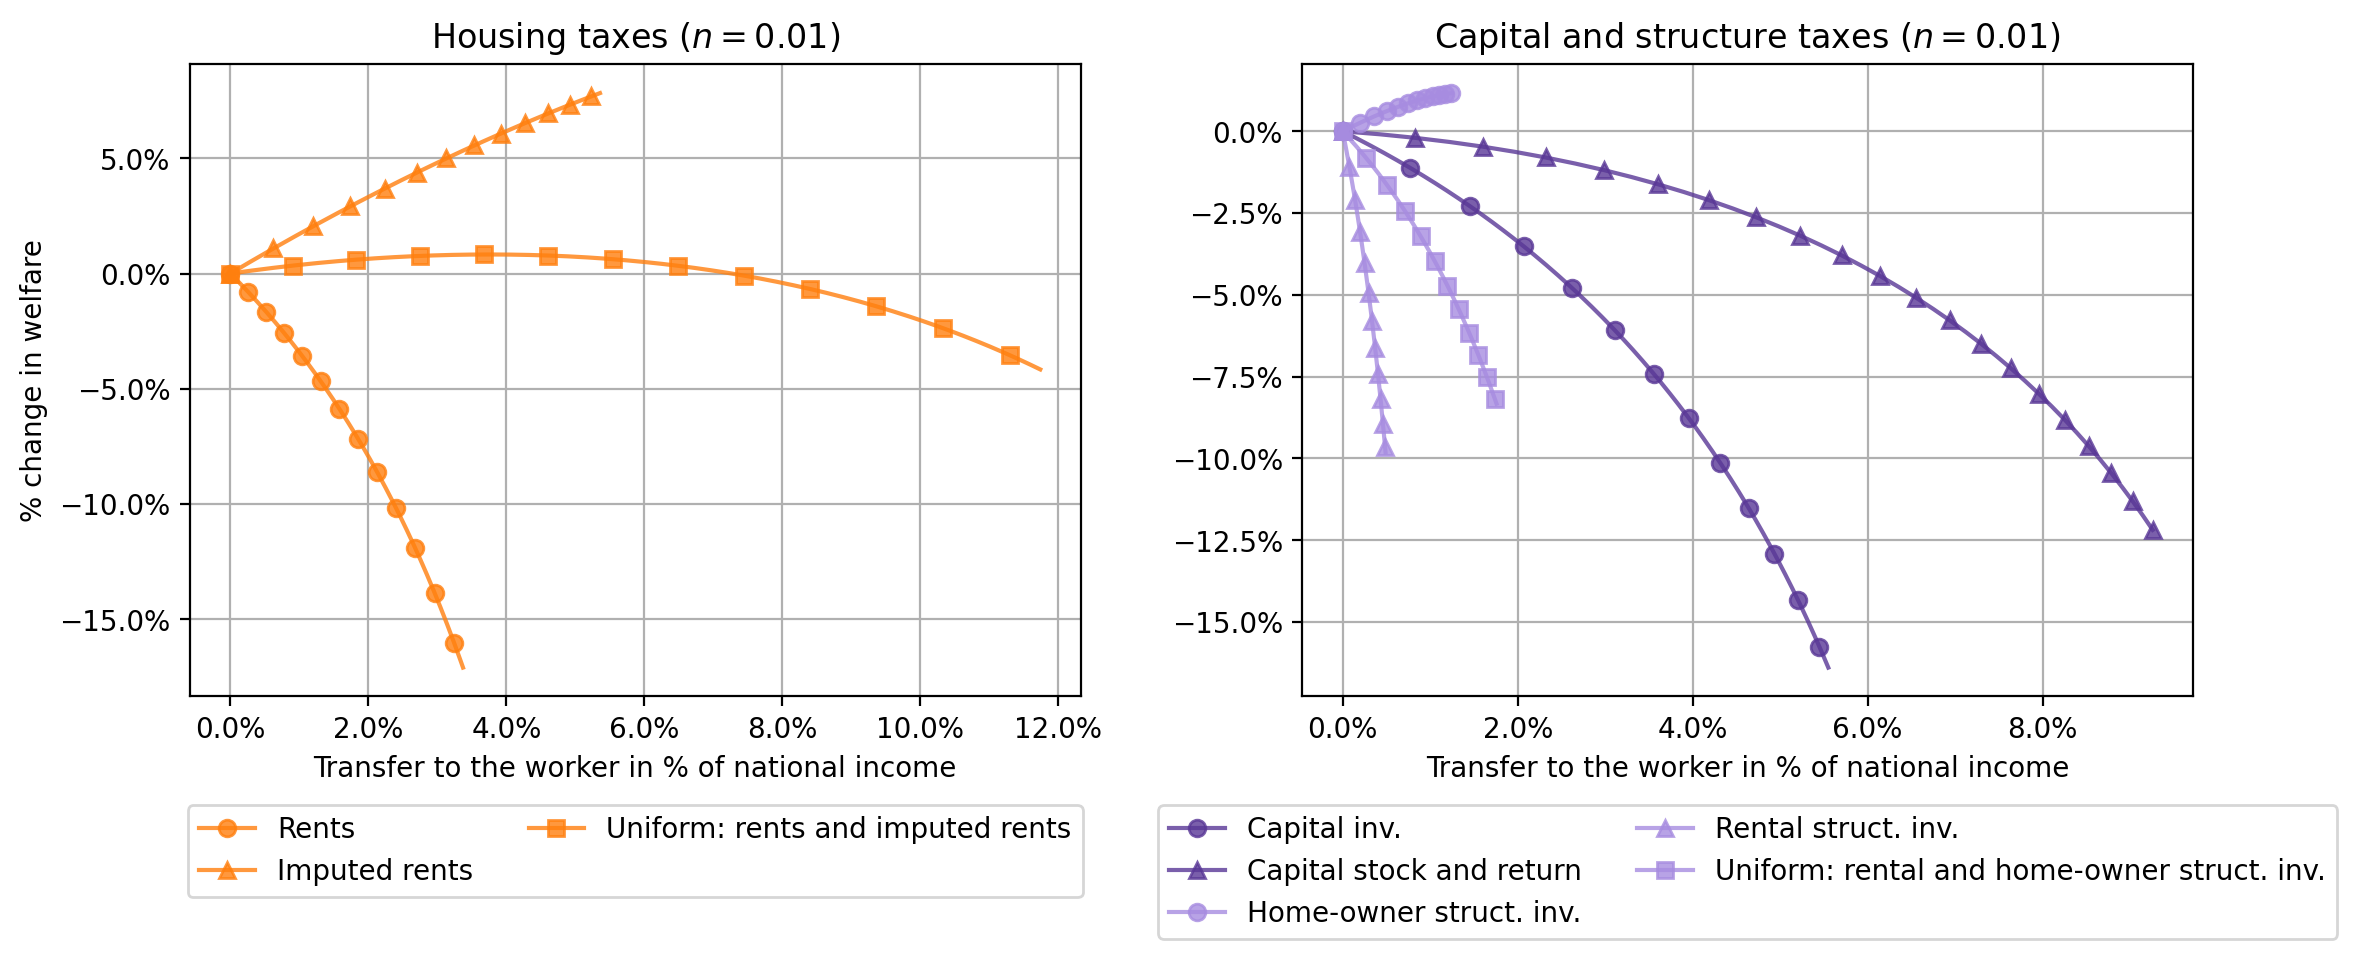

In [5]:

# ----------------------- Figure 4: taxes on housing, capital and structure (truncated) ------------------------
df_h_trunc  = df_h.query('tau_H <= 0.5')
df_H_trunc  = df_H.query('tau_HI <= 0.5')
df_uniformHh_trunc  = df_uniformHh.query('tau_H <= 0.5')
df_K_inv_trunc      = df_K_inv.query('tau_K_inv <= 0.5')
df_K_trunc  = df_K.query('tau_K <= 0.08')
df_S_trunc  = df_S.query('tau_S_inv <= 0.9')
df_s_trunc  = df_s.query('tau_s_inv <= 0.9')
df_uniformSs_trunc  = df_uniformSs.query('tau_S_inv <= 0.9')



fig, ax1 = plt.subplots(1,2, figsize=[12,5], dpi=200)
ax1[0].plot(df_h_trunc['transfer %'], df_h_trunc['welfare %'], linestyle='-', marker='o', color='tab:orange', 
         label='Rents', alpha=0.8, markevery=20)
ax1[0].plot(df_H_trunc['transfer %'], df_H_trunc['welfare %'], linestyle='-', marker='^', color='tab:orange', 
         label='Imputed rents', alpha=0.8, markevery=20)
ax1[0].plot(df_uniformHh_trunc['transfer %'], df_uniformHh_trunc['welfare %'], linestyle='-', marker='s', color='tab:orange', 
         label='Uniform: rents and imputed rents', alpha=0.8, markevery=20)

ax1[1].plot(df_K_inv_trunc['transfer %'], df_K_inv_trunc['welfare %'], linestyle='-', marker='o', color='#593796', 
         label='Capital inv.', alpha=0.8, markevery=20)
ax1[1].plot(df_K_trunc['transfer %'], df_K_trunc['welfare %'], linestyle='-', marker='^', color='#593796', 
         label='Capital stock and return', alpha=0.8, markevery=2)

ax1[1].plot(df_S_trunc['transfer %'], df_S_trunc['welfare %'], linestyle='-', marker='o', color='#A78CE0', 
         label='Home-owner struct. inv.', alpha=0.8, markevery=40)
ax1[1].plot(df_s_trunc['transfer %'], df_s_trunc['welfare %'], linestyle='-', marker='^', color='#A78CE0', 
         label='Rental struct. inv.', alpha=0.8, markevery=40)
ax1[1].plot(df_uniformSs_trunc['transfer %'], df_uniformSs_trunc['welfare %'], linestyle='-', marker='s', color='#A78CE0', 
         label='Uniform: rental and home-owner struct. inv.', alpha=0.8, markevery=40)

ax1[0].set_xlabel('Transfer to the worker in % of national income')
ax1[0].set_ylabel('% change in welfare')
ax1[0].set_title(f"Housing taxes ($n={params_exog['n']}$)")
ax1[0].legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax1[0].grid()
ax1[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax1[1].set_xlabel('Transfer to the worker in % of national income')
# ax2.set_ylabel('% change in welfare')
ax1[1].set_title(f"Capital and structure taxes ($n={params_exog['n']}$)")
ax1[1].legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax1[1].grid()
ax1[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

fig.tight_layout()

if savefig==1:
    plt.savefig('Figures/Fig4_taxes_on_housing_KSs_truncated.png', bbox_inches='tight')
plt.show()



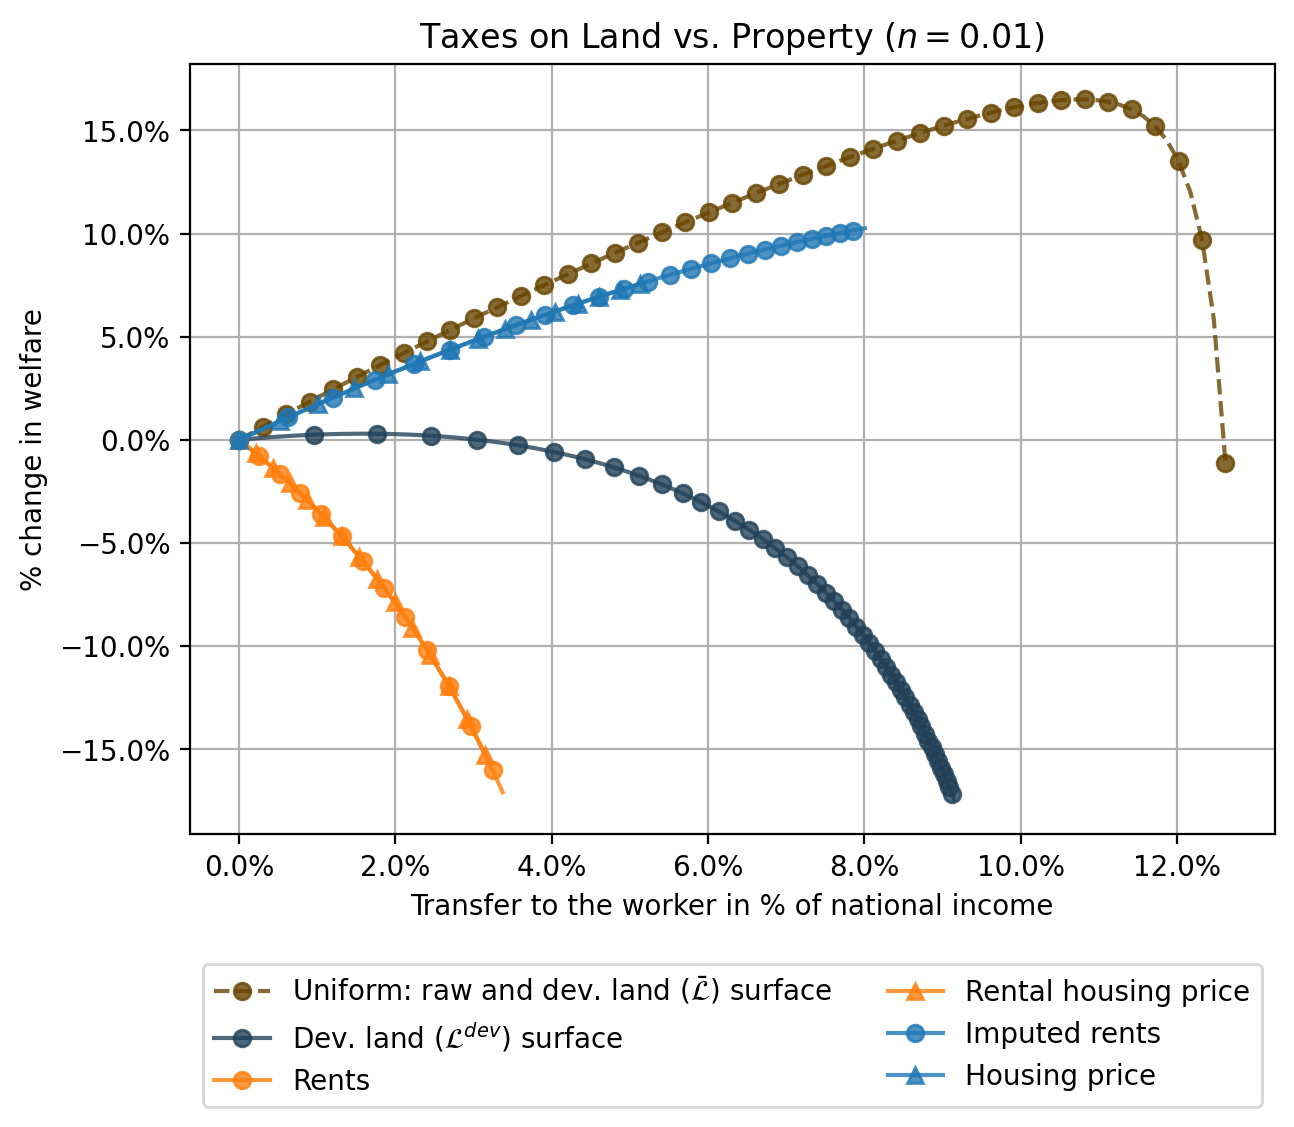

In [6]:
# get housing price and rental housing price
df_ph_trunc   = all_sol['Rental housing price'].query('sol_flag==0').query('tau_H <= 0.5')
df_pH_trunc   = all_sol['Housing price'].query('sol_flag==0').query('tau_HI <= 0.5')



fig, ax1 = plt.subplots(1, 1, figsize=[7, 5], dpi=200)

# Plot data on a single axis ax1
ax1.plot(df_uniformL_surface['transfer %'], df_uniformL_surface['welfare %'], linestyle='--', marker='o', color='#674500', 
         label=r'Uniform: raw and dev. land ($\bar{\mathcal{L}}$) surface', alpha=0.8, markevery=2)
ax1.plot(df_LDV_surface['transfer %'], df_LDV_surface['welfare %'], linestyle='-', marker='o', color='#224158', 
         label=r'Dev. land ($\mathcal{L}^{dev}$) surface', alpha=0.8, markevery=10)
ax1.plot(df_h_trunc['transfer %'], df_h_trunc['welfare %'], linestyle='-', marker='o', color='tab:orange', 
         label='Rents', alpha=0.8, markevery=20)
ax1.plot(df_ph_trunc['transfer %'], df_ph_trunc['welfare %'], linestyle='-', marker='^', color='tab:orange', 
         label='Rental housing price', alpha=0.8, markevery=1)
ax1.plot(df_H['transfer %'], df_H['welfare %'], linestyle='-', marker='o', color='tab:blue', 
         label='Imputed rents', alpha=0.8, markevery=20)
ax1.plot(df_pH_trunc['transfer %'], df_pH_trunc['welfare %'], linestyle='-', marker='^', color='tab:blue', 
         label='Housing price', alpha=0.8, markevery=1)


# Set labels, title, legend, and formatting on a single axis
ax1.set_xlabel('Transfer to the worker in % of national income')
ax1.set_ylabel('% change in welfare')
ax1.set_title(f"Taxes on Land vs. Property ($n={params_exog['n']}$)")
ax1.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax1.grid()
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))


if savefig==1:
    plt.savefig('Figures/Fig13_taxes_landvsproperty.png', bbox_inches='tight')
plt.show()


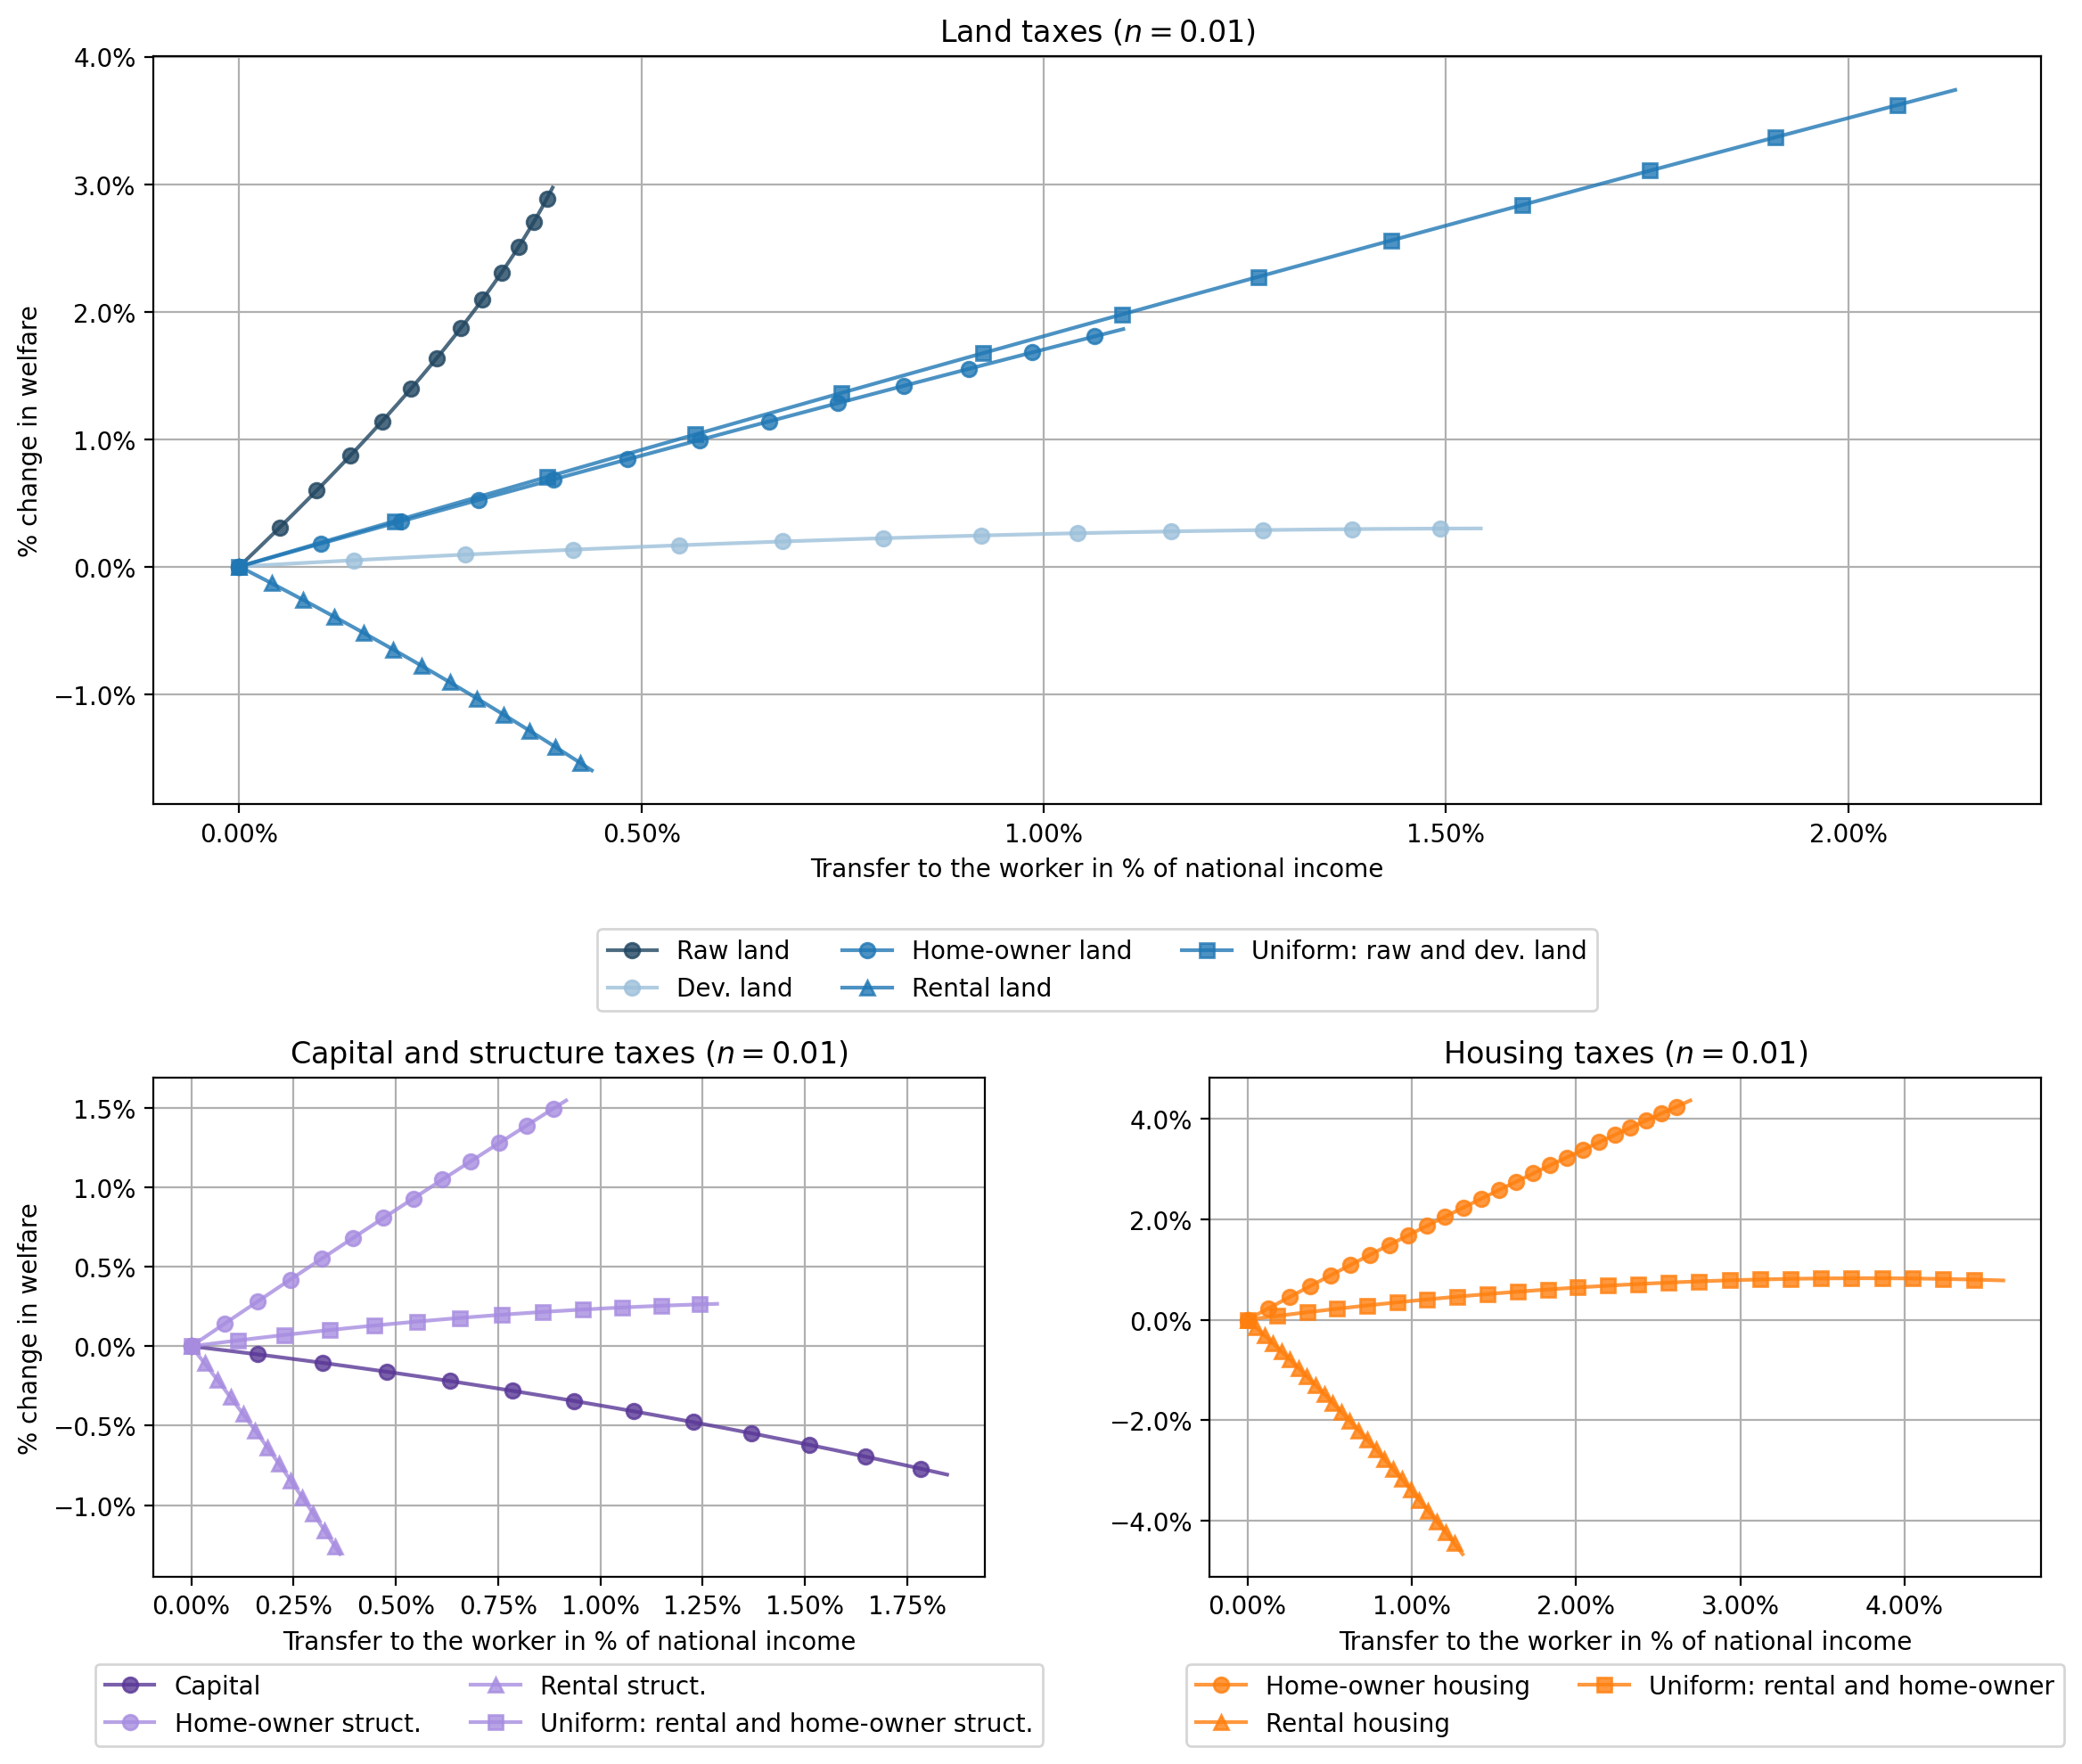

In [7]:

# ----------------------- Figure 5: all taxes on inheritance and bequests ------------------------

# land taxes
df_LR_DI  = all_sol['DI_Raw land'].query('sol_flag==0')
df_uniformL_DI     = all_sol['DI_Uniform: raw and dev. land'].query('sol_flag==0')
df_LDV_DI  = all_sol['DI_Dev. land'].query('sol_flag==0')
df_L_DI  = all_sol['DI_Home-owner land'].query('sol_flag==0')
df_l_DI    = all_sol['DI_Rental land'].query('sol_flag==0')

# KSs taxes
df_K_DI  = all_sol['DI_Capital'].query('sol_flag==0')
df_S_DI     = all_sol['DI_Home-owner struct.'].query('sol_flag==0')
df_s_DI  = all_sol['DI_Rental struct.'].query('sol_flag==0')
df_uniformSs_DI  = all_sol['DI_Uniform: rental and home-owner struct.'].query('sol_flag==0')

# housing taxes
df_H_DI  = all_sol['DI_Home-owner housing'].query('sol_flag==0')
df_h_DI    = all_sol['DI_Rental housing'].query('sol_flag==0')
df_uniformHh_DI  = all_sol['DI_Uniform: rental and home-owner'].query('sol_flag==0')


###################### create plot ######################

fig = plt.figure(figsize=[12, 10], dpi=200)
gs = GridSpec(nrows=2, ncols=2, height_ratios=[0.6, 0.4])
ax0 = fig.add_subplot(gs[0,:])
ax1 = fig.add_subplot(gs[1,0])
ax2 = fig.add_subplot(gs[1,1])


# land taxes
ax0.plot(df_LR_DI['transfer %'], df_LR_DI['welfare %'], linestyle='-', marker='o', color='#214661', 
         label='Raw land', alpha=0.8, markevery=40)
ax0.plot(df_LDV_DI['transfer %'], df_LDV_DI['welfare %'], linestyle='-', marker='o', color='#9cc0da', 
         label='Dev. land', alpha=0.8, markevery=40)
ax0.plot(df_L_DI['transfer %'], df_L_DI['welfare %'], linestyle='-', marker='o', color='#1f77b4', 
         label='Home-owner land', alpha=0.8, markevery=40)
ax0.plot(df_l_DI['transfer %'], df_l_DI['welfare %'], linestyle='-', marker='^', color='#1f77b4', 
         label='Rental land', alpha=0.8, markevery=40)
ax0.plot(df_uniformL_DI['transfer %'], df_uniformL_DI['welfare %'], linestyle='-', marker='s', color='#1f77b4', 
         label='Uniform: raw and dev. land', alpha=0.8, markevery=40)

# capital structure taxes
ax1.plot(df_K_DI['transfer %'], df_K_DI['welfare %'], linestyle='-', marker='o', color='#593796', 
         label='Capital', alpha=0.8, markevery=40)
ax1.plot(df_S_DI['transfer %'], df_S_DI['welfare %'], linestyle='-', marker='o', color='#A78CE0', 
         label='Home-owner struct.', alpha=0.8, markevery=40)
ax1.plot(df_s_DI['transfer %'], df_s_DI['welfare %'], linestyle='-', marker='^', color='#A78CE0', 
         label='Rental struct.', alpha=0.8, markevery=40)
ax1.plot(df_uniformSs_DI['transfer %'], df_uniformSs_DI['welfare %'], linestyle='-', marker='s', color='#A78CE0', 
         label='Uniform: rental and home-owner struct.', alpha=0.8, markevery=40)

# housing taxes
ax2.plot(df_H_DI['transfer %'], df_H_DI['welfare %'], linestyle='-', marker='o', color='tab:orange', 
         label='Home-owner housing', alpha=0.8, markevery=20)
ax2.plot(df_h_DI['transfer %'], df_h_DI['welfare %'], linestyle='-', marker='^', color='tab:orange', 
         label='Rental housing', alpha=0.8, markevery=20)
ax2.plot(df_uniformHh_DI['transfer %'], df_uniformHh_DI['welfare %'], linestyle='-', marker='s', color='tab:orange', 
         label='Uniform: rental and home-owner', alpha=0.8, markevery=20)

ax0.set_xlabel('Transfer to the worker in % of national income')
ax0.set_ylabel('% change in welfare')
ax0.set_title(f"Land taxes ($n={params_exog['n']}$)")
ax0.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax0.grid()
ax0.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
ax0.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

ax1.set_xlabel('Transfer to the worker in % of national income')
ax1.set_ylabel('% change in welfare')
ax1.set_title(f"Capital and structure taxes ($n={params_exog['n']}$)")
ax1.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax1.grid()
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

ax2.set_xlabel('Transfer to the worker in % of national income')
# ax2.set_ylabel('% change in welfare')
ax2.set_title(f"Housing taxes ($n={params_exog['n']}$)")
ax2.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax2.grid()
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

fig.tight_layout()

if savefig==1:
    plt.savefig('Figures/Fig5_taxes_DI.png', bbox_inches='tight')
plt.show()




In [8]:

# ----------------------- Figure 6: compare taxes on land with or without population growth ------------------------
# solve n=0 steady state
params_exog_neq0 = params_exog.copy()
params_exog_neq0['n'] = 0.0

sol_taxeq0_neq0 = solve_ss(params_exog_neq0, params_endog1, taxes_eq0, init_guess)

NatIncome_taxeq0_neq0 = sol_taxeq0_neq0['NatIncome_prod']
welfare_taxeq0_neq0   = sol_taxeq0_neq0['welfare']

with open('sol_uncons_taxeq0_neq0.json', 'w') as js:
    json.dump(sol_taxeq0_neq0, js)

sol_calib_neq0 = solve_ss(params_exog_neq0, params_endog1, taxes_calib, init_guess)
    
# create table
create_table(sol_calib_neq0, sol_taxeq0_neq0, targets)
print(latex_table(sol_calib_neq0, sol_taxeq0_neq0, targets))

# ------------ simulate the steady state tax change -------------
print('\n------------- Simulate all taxes -------------')
all_sol_neq0 = dict()

# start and end tax rate
tau_start = 0
tau_end   = 1
num_step  = 500

for tax_name, taxes in all_tax:
    print(f'Progress: simulating tax on {tax_name}')
    
    # simulate comparative statics
    if tax_name in [
        'Capital stock and return',         # brentq does not work
        'Total land sale by rentiers'       #  tau_LR_sale = 1 => division by 0 in computing p_R
            ]:
        a = tau_start
        b = tau_end - 1e-2
    else:
        a = tau_start
        b = tau_end
    
    tax_dict = dict.fromkeys(taxes, np.linspace(a, b, num_step))
    
    if tax_name != 'Uniform value: raw and dev. land value':
        df = comp_stat_tax(params_exog_neq0, params_endog1, taxes_eq0, tax_dict, sol_taxeq0)
    
    else:
        tau_L_value = np.linspace(0.0, 0.18,  100)

        tax_dict = {
            'tau_L_value': tau_L_value,
            'tau_l_value': tau_L_value
        }
    
        df = comp_stat_tax(params_exog_neq0, params_endog1,   # taxes are uniform
                        taxes_eq0, tax_dict, sol_taxeq0, uniformval=1)

    
    # compute welfare change and nat income transfer relative to Laissez faire economy
    df['welfare %'] = (df['welfare'] - welfare_taxeq0_neq0)/np.abs(welfare_taxeq0_neq0)
    df['transfer %'] = df['T_total']/NatIncome_taxeq0_neq0
    
    all_sol_neq0[tax_name] = df

# store solutions in excel spreadsheets
for tax_name in all_sol_neq0.keys():
    df = all_sol_neq0[tax_name]
    df.to_excel(f'comparative_statics_all_taxes_uncons_neq0/{tax_name}.xlsx')



+-----------------------------+-----------------------+----------------------+----------------------+---------------------+
|             Name            |         Symbol        |      Calibrated      |    Laissez faire     |        Target       |
+-----------------------------+-----------------------+----------------------+----------------------+---------------------+
|       Capitalist cons.      |           C           |  1.405446076439604   |  1.4422739225197196  |          -          |
|  Worker cons. (per worker)  |           c           |  0.762673323037318   |  0.7643663008240426  |          -          |
| Rentier cons. (per rentier) |          C_R          |  1.722526561517573   |  1.5956073272593334  |          -          |
|       Home-owner land       |           L           |  1.1464655437823301  |  1.1765062119742116  |          -          |
|         Rental land         |           l           | 0.43279030342988994  |  0.4337509149411702  |          -          |
|       

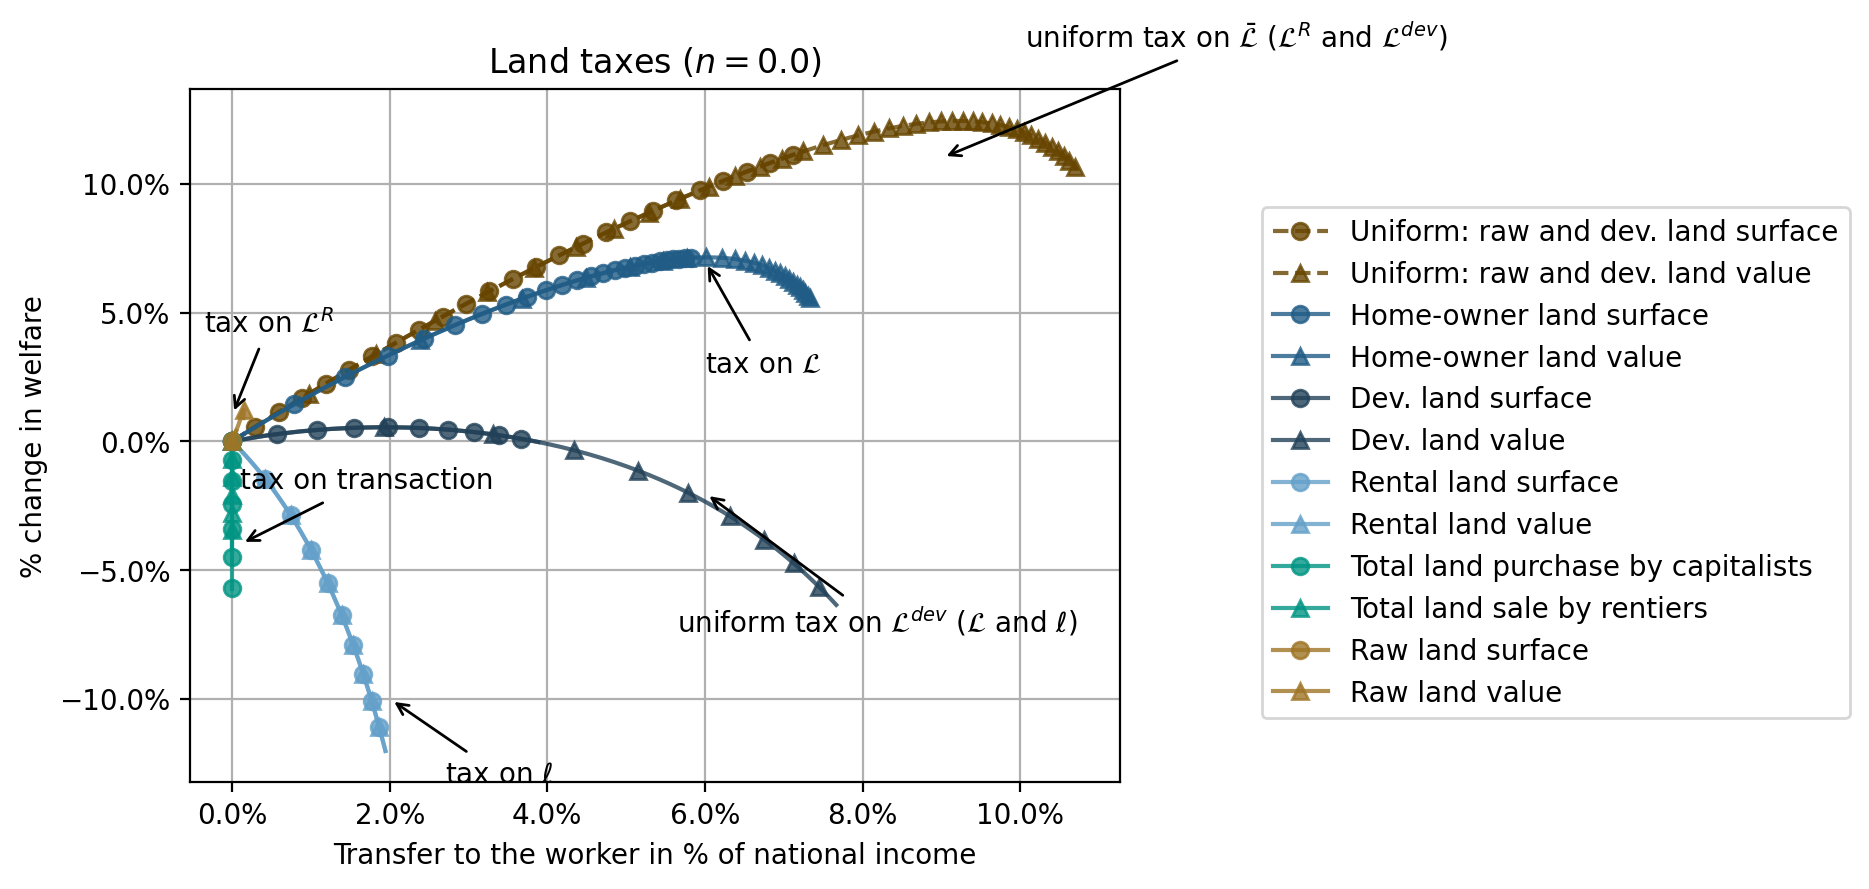

In [9]:

# retreive all land taxes
df_LR_surface_neq0   = all_sol_neq0['Raw land surface'].query('sol_flag==0')
df_LR_value_neq0     = all_sol_neq0['Raw land value'].query('sol_flag==0')
df_LDV_surface_neq0  = all_sol_neq0['Dev. land surface'].query('sol_flag==0')
df_LDV_value_neq0    = all_sol_neq0['Dev. land value'].query('sol_flag==0')
df_L_surface_neq0    = all_sol_neq0['Home-owner land surface'].query('sol_flag==0')
df_L_value_neq0      = all_sol_neq0['Home-owner land value'].query('sol_flag==0')
df_l_surface_neq0    = all_sol_neq0['Rental land surface'].query('sol_flag==0')
df_l_value_neq0      = all_sol_neq0['Rental land value'].query('sol_flag==0')
df_uniformL_surface_neq0     = all_sol_neq0['Uniform: raw and dev. land surface'].query('sol_flag==0')
df_uniformLrate_value_neq0       = all_sol_neq0['Uniform rate: raw and dev. land value'].query('sol_flag==0')
df_uniformLvalue_value_neq0       = all_sol_neq0['Uniform value: raw and dev. land value'].query('sol_flag==0')
df_land_sale_neq0            = all_sol_neq0['Total land sale by rentiers'].query('sol_flag==0')
df_land_purchase_neq0        = all_sol_neq0['Total land purchase by capitalists'].query('sol_flag==0')


# plot
df_LR_surface_neq0_trunc   = df_LR_surface_neq0.query('tau_LR_surface <= 0.006')
df_LR_value_neq0_trunc     = df_LR_value_neq0.query('tau_LR_value <= 0.01')
df_LDV_surface_neq0_trunc  = df_LDV_surface_neq0.query('tau_L_surface <= 0.1')
df_LDV_value_neq0_trunc    = df_LDV_value_neq0.query('tau_L_value <= 0.1')
df_L_surface_neq0_trunc    = df_L_surface_neq0.query('tau_L_surface <= 0.5')
df_L_value_neq0_trunc      = df_L_value_neq0.query('tau_L_value <= 0.5')
df_l_surface_neq0_trunc    = df_l_surface_neq0.query('tau_l_surface <= 0.3')
df_l_value_neq0_trunc      = df_l_value.query('tau_l_value <= 0.3')
df_uniformL_surface_neq0_trunc     = df_uniformL_surface_neq0.query('tau_LR_surface <= 0.1')
df_uniformLvalue_value_neq0_trunc  = df_uniformLvalue_value_neq0.query('tau_LR_value <= 0.3')
df_land_sale_neq0_trunc            = df_land_sale_neq0.query('tau_LR_sale <= 0.3')
df_land_purchase_neq0_trunc        = df_land_purchase_neq0.query('tau_LDV_sale <= 0.3')


fig0, ax0 = plt.subplots(1,1, figsize=[6,4.5],dpi=200)


ax0.plot(df_uniformL_surface_neq0_trunc['transfer %'], df_uniformL_surface_neq0_trunc['welfare %'], linestyle='--', marker='o', color='#674500', 
         label='Uniform: raw and dev. land surface', alpha=0.8, markevery=2)

ax0.plot(df_uniformLvalue_value_neq0_trunc['transfer %'], df_uniformLvalue_value_neq0_trunc['welfare %'], linestyle='--', marker='^', color='#674500', 
         label='Uniform: raw and dev. land value',alpha=0.8, markevery=2)

ax0.plot(df_L_surface_neq0_trunc['transfer %'], df_L_surface_neq0_trunc['welfare %'], linestyle='-', marker='o', color='#205c86', 
         label='Home-owner land surface', alpha=0.8, markevery=10)
ax0.plot(df_L_value_neq0_trunc['transfer %'], df_L_value_neq0_trunc['welfare %'], linestyle='-', marker='^', color='#205c86', 
         label='Home-owner land value', alpha=0.8, markevery=10)

ax0.plot(df_LDV_surface_neq0_trunc['transfer %'], df_LDV_surface_neq0_trunc['welfare %'], linestyle='-', marker='o', color='#224158', 
         label='Dev. land surface', alpha=0.8, markevery=5)
ax0.plot(df_LDV_value_neq0_trunc['transfer %'], df_LDV_value_neq0_trunc['welfare %'], linestyle='-', marker='^', color='#224158', 
         label='Dev. land value', alpha=0.8, markevery=5)

ax0.plot(df_l_surface_neq0_trunc['transfer %'], df_l_surface_neq0_trunc['welfare %'], linestyle='-', marker='o', color='#64a0c9', 
         label='Rental land surface', alpha=0.8, markevery=15)
ax0.plot(df_l_surface_neq0_trunc['transfer %'], df_l_surface_neq0_trunc['welfare %'], linestyle='-', marker='^', color='#64a0c9', 
         label='Rental land value', alpha=0.8, markevery=15)

ax0.plot(df_land_sale_neq0_trunc['transfer %'], df_land_sale_neq0_trunc['welfare %'], linestyle='-', marker='o', color='#009583', 
         label='Total land purchase by capitalists', alpha=0.8, markevery=25)
ax0.plot(df_land_purchase_neq0_trunc['transfer %'], df_land_purchase_neq0_trunc['welfare %'], linestyle='-', marker='^', color='#009583', 
         label='Total land sale by rentiers', alpha=0.8, markevery=25)

ax0.plot(df_LR_surface_neq0_trunc['transfer %'], df_LR_surface_neq0_trunc['welfare %'], linestyle='-', marker='o', color='#9F7526', 
         label='Raw land surface', alpha=0.8, markevery=3)
ax0.plot(df_LR_value_neq0_trunc['transfer %'], df_LR_value_neq0_trunc['welfare %'], linestyle='-', marker='^', color='#9F7526', 
         label='Raw land value', alpha=0.8, markevery=3)



ax0.set_xlabel('Transfer to the worker in % of national income')
ax0.set_ylabel('% change in welfare')
ax0.set_title(f"Land taxes ($n={params_exog_neq0['n']}$)")
ax0.legend(ncol=1, loc='upper right', bbox_to_anchor=(1.8, 0.85))
ax0.grid()
ax0.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax0.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))


ax0.annotate(r'tax on $\mathcal{L}^R$', 
             xy=[0/100, 1/100], xycoords='data',
             xytext=[-10, 30], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'uniform tax on $\bar{\mathcal{L}}$ ($\mathcal{L}^R$ and $\mathcal{L}^{dev}$)',
             xy=[9/100, 11/100], xycoords='data',
             xytext=[30, 40], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'uniform tax on $\mathcal{L}^{dev}$ ($\mathcal{L}$ and $\ell$)', 
             xy=[6/100, -2/100], xycoords='data',
             xytext=[-10, -50], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'tax on $\mathcal{L}$', 
             xy=[6/100, 7/100], xycoords='data',
             xytext=[0, -40], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'tax on $\ell$',
            xy=[2/100, -10/100], xycoords='data',
             xytext=[20, -30], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)
ax0.annotate(r'tax on transaction', 
             xy=[0.1/100, -4/100], xycoords='data',
             xytext=[0, 20], textcoords='offset points', 
             arrowprops=dict(arrowstyle="->"), zorder=100)

fig.tight_layout()

if savefig==1:
    plt.savefig('Figures/Fig6_taxes_on_land_truncated_neq0.png', bbox_inches='tight')


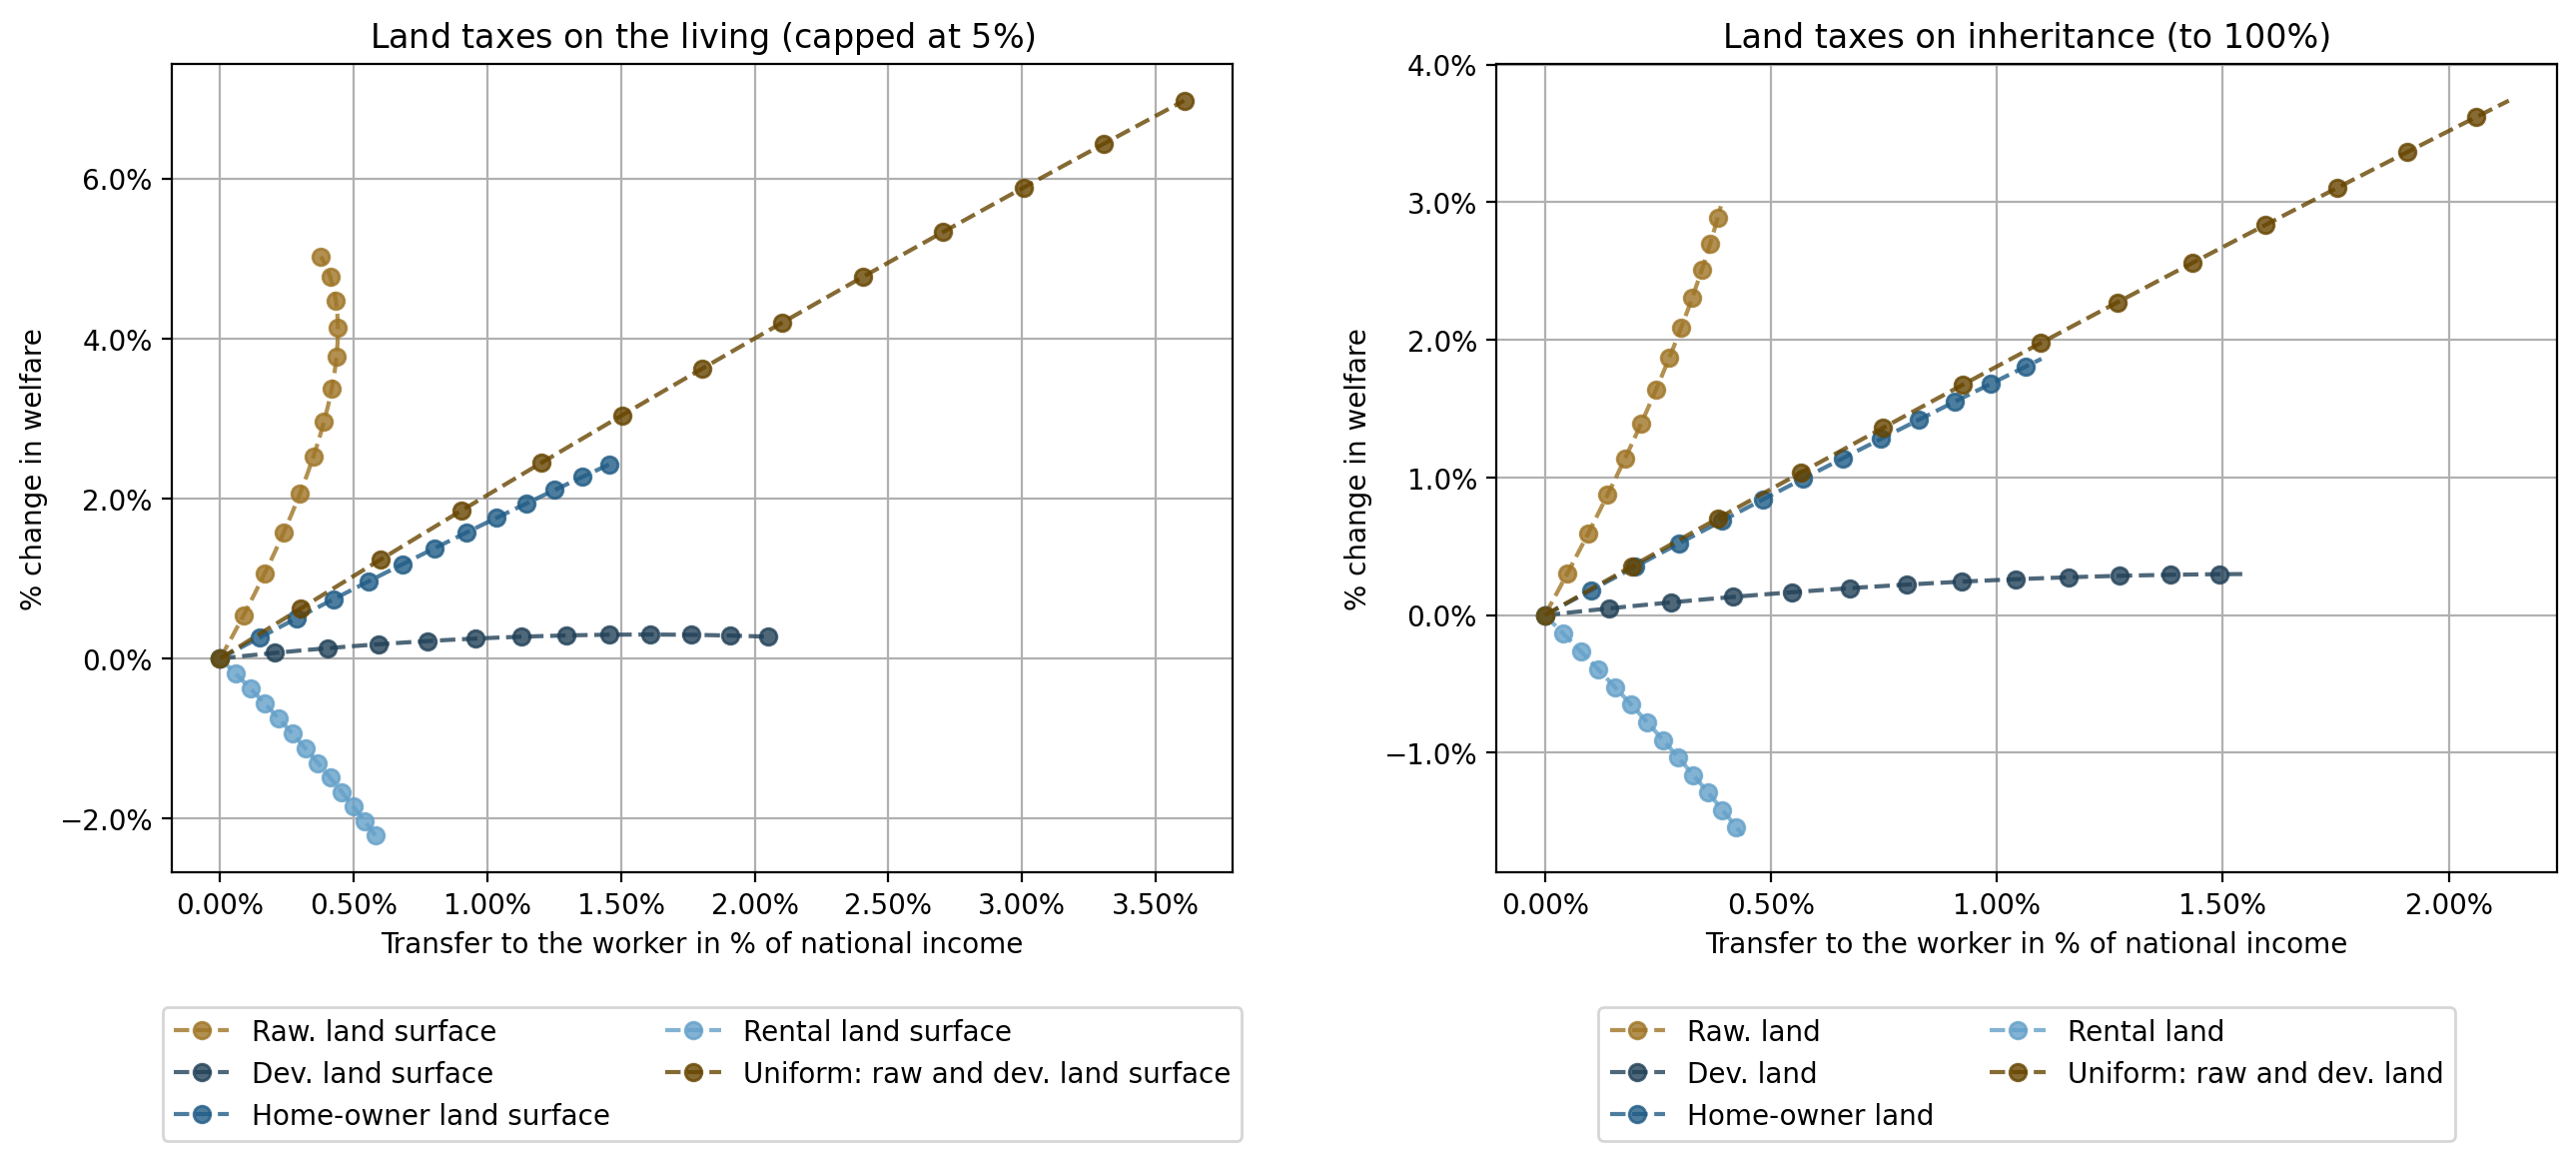

In [10]:

# ----------------------- Figure 7: compare all taxes: on the living vs. on inheritance  ------------------------

# truncate tax on the living
df_LR_surface_fig7   = df_LR_surface.query('tau_LR_surface <= 0.05')
df_LDV_surface_fig7  = df_LDV_surface.query('tau_L_surface <= 0.05')
df_L_surface_fig7    = df_L_surface.query('tau_L_surface <= 0.05')
df_l_surface_fig7    = df_l_surface.query('tau_l_surface <= 0.05')
df_uniformL_surface_fig7     = df_uniformL_surface.query('tau_LR_surface <= 0.05')



fig, ax = plt.subplots(1, 2, figsize=[13, 6], dpi=200)

ax[0].plot(df_LR_surface_fig7['transfer %'], df_LR_surface_fig7['welfare %'], linestyle='--', marker='o', color='#9F7526', 
         label='Raw. land surface', alpha=0.8, markevery=2)
ax[0].plot(df_LDV_surface_fig7['transfer %'], df_LDV_surface_fig7['welfare %'], linestyle='--', marker='o', color='#224158', 
         label='Dev. land surface', alpha=0.8, markevery=2)
ax[0].plot(df_L_surface_fig7['transfer %'], df_L_surface_fig7['welfare %'], linestyle='--', marker='o', color='#205c86', 
         label='Home-owner land surface', alpha=0.8, markevery=2)
ax[0].plot(df_l_surface_fig7['transfer %'], df_l_surface_fig7['welfare %'], linestyle='--', marker='o', color='#64a0c9', 
         label='Rental land surface', alpha=0.8, markevery=2)
ax[0].plot(df_uniformL_surface_fig7['transfer %'], df_uniformL_surface_fig7['welfare %'], linestyle='--', marker='o', color='#674500', 
         label='Uniform: raw and dev. land surface', alpha=0.8, markevery=2)

ax[1].plot(df_LR_DI['transfer %'], df_LR_DI['welfare %'], linestyle='--', marker='o', color='#9F7526', 
         label='Raw. land', alpha=0.8, markevery=40)
ax[1].plot(df_LDV_DI['transfer %'], df_LDV_DI['welfare %'], linestyle='--', marker='o', color='#224158', 
         label='Dev. land', alpha=0.8, markevery=40)
ax[1].plot(df_L_DI['transfer %'], df_L_DI['welfare %'], linestyle='--', marker='o', color='#205c86', 
         label='Home-owner land', alpha=0.8, markevery=40)
ax[1].plot(df_l_DI['transfer %'], df_l_DI['welfare %'], linestyle='--', marker='o', color='#64a0c9', 
         label='Rental land', alpha=0.8, markevery=40)
ax[1].plot(df_uniformL_DI['transfer %'], df_uniformL_DI['welfare %'], linestyle='--', marker='o', color='#674500', 
         label='Uniform: raw and dev. land', alpha=0.8, markevery=40)


# other label
ax[0].set_xlabel('Transfer to the worker in % of national income')
ax[0].set_ylabel('% change in welfare')
ax[0].set_title(r"Land taxes on the living (capped at $5\%$)")
ax[0].legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax[0].grid()
ax[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
ax[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

ax[1].set_xlabel('Transfer to the worker in % of national income')
ax[1].set_ylabel('% change in welfare')
ax[1].set_title(r"Land taxes on inheritance (to 100%)")
ax[1].legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax[1].grid()
ax[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

# turn label on
ax[1].yaxis.set_tick_params(labelleft=True)

fig.tight_layout()

if savefig==1:
    plt.savefig('Figures/Fig7_comparison_living_vs_inher.png', bbox_inches='tight')
    
    
    

# Fully extended


# # ----------------------- Figure 7: compare all taxes: on the living vs. on inheritance  ------------------------

# # truncate tax on the living
# df_LR_surface_fig7   = df_LR_surface.query('tau_LR_surface <= 1')
# df_LDV_surface_fig7  = df_LDV_surface.query('tau_L_surface <= 1')
# df_L_surface_fig7    = df_L_surface.query('tau_L_surface <= 1')
# df_l_surface_fig7    = df_l_surface.query('tau_l_surface <= 1')
# df_uniformL_surface_fig7     = df_uniformL_surface.query('tau_LR_surface <= 1')



# fig, ax = plt.subplots(1, 2, figsize=[13, 6], dpi=200)

# ax[0].plot(df_LR_surface_fig7['transfer %'], df_LR_surface_fig7['welfare %'], linestyle='--', marker='o', color='#9F7526', 
#          label='Raw. land surface', alpha=0.8, markevery=20)
# ax[0].plot(df_LDV_surface_fig7['transfer %'], df_LDV_surface_fig7['welfare %'], linestyle='--', marker='o', color='#224158', 
#          label='Dev. land surface', alpha=0.8, markevery=20)
# ax[0].plot(df_L_surface_fig7['transfer %'], df_L_surface_fig7['welfare %'], linestyle='--', marker='o', color='#205c86', 
#          label='Home-owner land surface', alpha=0.8, markevery=20)
# ax[0].plot(df_l_surface_fig7['transfer %'], df_l_surface_fig7['welfare %'], linestyle='--', marker='o', color='#64a0c9', 
#          label='Rental land surface', alpha=0.8, markevery=20)
# ax[0].plot(df_uniformL_surface_fig7['transfer %'], df_uniformL_surface_fig7['welfare %'], linestyle='--', marker='o', color='#674500', 
#          label='Uniform: raw and dev. land surface', alpha=0.8, markevery=5)

# ax[1].plot(df_LR_DI['transfer %'], df_LR_DI['welfare %'], linestyle='--', marker='o', color='#9F7526', 
#          label='Raw. land', alpha=0.8, markevery=40)
# ax[1].plot(df_LDV_DI['transfer %'], df_LDV_DI['welfare %'], linestyle='--', marker='o', color='#224158', 
#          label='Dev. land', alpha=0.8, markevery=40)
# ax[1].plot(df_L_DI['transfer %'], df_L_DI['welfare %'], linestyle='--', marker='o', color='#205c86', 
#          label='Home-owner land', alpha=0.8, markevery=40)
# ax[1].plot(df_l_DI['transfer %'], df_l_DI['welfare %'], linestyle='--', marker='o', color='#64a0c9', 
#          label='Rental land', alpha=0.8, markevery=40)
# ax[1].plot(df_uniformL_DI['transfer %'], df_uniformL_DI['welfare %'], linestyle='--', marker='o', color='#674500', 
#          label='Uniform: raw and dev. land', alpha=0.8, markevery=40)


# # other label
# ax[0].set_xlabel('Transfer to the worker in % of national income')
# ax[0].set_ylabel('% change in welfare')
# ax[0].set_title(r"Land taxes on the living")
# ax[0].legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
# ax[0].grid()
# ax[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
# ax[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

# ax[1].set_xlabel('Transfer to the worker in % of national income')
# ax[1].set_ylabel('% change in welfare')
# ax[1].set_title(r"Land taxes on inheritance")
# ax[1].legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
# ax[1].grid()
# ax[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
# ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

# # turn label on
# ax[1].yaxis.set_tick_params(labelleft=True)

# fig.tight_layout()

# # if savefig==1:
# #     plt.savefig('Figures/Fig7_comparison_living_vs_inher.png', bbox_inches='tight')




In [11]:

# ##################################################################
# ####################  CONSTRAINED RAW LAND  ######################
# ##################################################################


params_endog_cons= {
    'cost_L1': 0,
    'cost_L2': 46.25, # 0.6418863472641582,
    'Lbar':   2.118954533473501,
    'R_R0':   0.04,
    'R_R1':   0.065,
    'kappa':  0.0025,
    'eta_b':  0.02
}

init_guess_cons= {
    'c'     : 0.75,
    'C'     : 1.22,
    'C_R'   : 2.96,
    's'     : 1.22,
    'S'     : 2.88,
    'l'     : 0.2,
    'L'     : 0.97, 
    'LR_1'  : 1,
    'Psi_R' : 0.9,
    'Psi_C' : 0.8,
}

sol_calib_cons= solve_ss_constructible(params_exog, params_endog_cons, taxes_calib, init_guess_cons)
sol_taxeq0_cons= solve_ss_constructible(params_exog, params_endog_cons, taxes_eq0, init_guess_cons)

create_table(sol_calib_cons, sol_taxeq0_cons, targets)
print(latex_table(sol_calib_cons, sol_taxeq0_cons, targets))



# store outcomes
with open('ParamEndog_cons_calib.json', 'w') as file:
    json.dump(params_endog_cons, file)

with open('sol_cons_calib.json', 'w') as js:
    json.dump(sol_calib_cons, js)

with open('sol_cons_taxeq0.json', 'w') as js:
    json.dump(sol_taxeq0_cons, js)
    
    
NatIncome_taxeq0_cons= sol_taxeq0_cons['NatIncome_prod']
welfare_taxeq0_cons  = sol_taxeq0_cons['welfare']



# ------------ simulate the steady state tax change -------------
print('\n------------- Simulate all taxes -------------')
all_sol_cons = dict()

# start and end tax rate
tau_start = 0
tau_end   = 1
num_step  = 200

for tax_name, taxes in all_tax:
    print(f'Progress: simulating tax on {tax_name}')
    
    # simulate comparative statics
    if tax_name in [
        'Capital stock and return',         # brentq does not work
        'Total land sale by rentiers'       #  tau_LR_sale = 1 => division by 0 in computing p_R
            ]:
        a = tau_start
        b = tau_end - 1e-2
    elif tax_name in ['Capital stock and return']:
        a = 0.11
        b = tau_end - 1e-2
    else:
        a = tau_start
        b = tau_end
        
    tax_dict = dict.fromkeys(taxes, np.linspace(a, b, num_step))
    
    df = comp_stat_tax(params_exog, params_endog_cons,   # taxes are uniform
                       taxes_eq0, tax_dict, sol_taxeq0_cons, constrained=1)
    
    # compute welfare change and nat income transfer relative to Laissez faire economy
    df['welfare %'] = (df['welfare'] - welfare_taxeq0_cons)/np.abs(welfare_taxeq0_cons)
    df['transfer %'] = df['T_total']/NatIncome_taxeq0_cons
    
    all_sol_cons[tax_name] = df

# store solutions in excel spreadsheets
for tax_name in all_sol_cons.keys():
    df = all_sol_cons[tax_name]
    df.to_excel(f'comparative_statics_all_taxes_cons/{tax_name}.xlsx')








    
# ----------------------------------------------------------------
# --------------------------- Plots ------------------------------
# ----------------------------------------------------------------

# retreive all land taxes
df_LR_surface_cons  = all_sol_cons['Raw land surface'].query('sol_flag==0')
df_LR_value_cons    = all_sol_cons['Raw land value'].query('sol_flag==0')
df_LDV_surface_cons = all_sol_cons['Dev. land surface'].query('sol_flag==0')
df_LDV_value_cons   = all_sol_cons['Dev. land value'].query('sol_flag==0')
df_L_surface_cons   = all_sol_cons['Home-owner land surface'].query('sol_flag==0')
df_L_value_cons     = all_sol_cons['Home-owner land value'].query('sol_flag==0')
df_l_surface_cons   = all_sol_cons['Rental land surface'].query('sol_flag==0')
df_l_value_cons     = all_sol_cons['Rental land value'].query('sol_flag==0')
df_uniformL_surface_cons    = all_sol_cons['Uniform: raw and dev. land surface'].query('sol_flag==0')
df_uniformL_value_cons      = all_sol_cons['Uniform rate: raw and dev. land value'].query('sol_flag==0')
df_land_sale_cons           = all_sol_cons['Total land sale by rentiers'].query('sol_flag==0')
df_land_purchase_cons       = all_sol_cons['Total land purchase by capitalists'].query('sol_flag==0')


+-----------------------------+-----------------------+----------------------+---------------------+---------------------+
|             Name            |         Symbol        |      Calibrated      |    Laissez faire    |        Target       |
+-----------------------------+-----------------------+----------------------+---------------------+---------------------+
|       Capitalist cons.      |           C           |  1.2703198085652172  |  1.300666472451191  |          -          |
|  Worker cons. (per worker)  |           c           |  0.7361755399784283  |  0.7376318877548346 |          -          |
| Rentier cons. (per rentier) |          C_R          |  2.609662464810672   |  2.6283154334283347 |          -          |
|       Home-owner land       |           L           | 0.29903907590636414  | 0.30088906252905245 |          -          |
|         Rental land         |           l           | 0.12055588121710137  | 0.11870589459441307 |          -          |
|        Develop

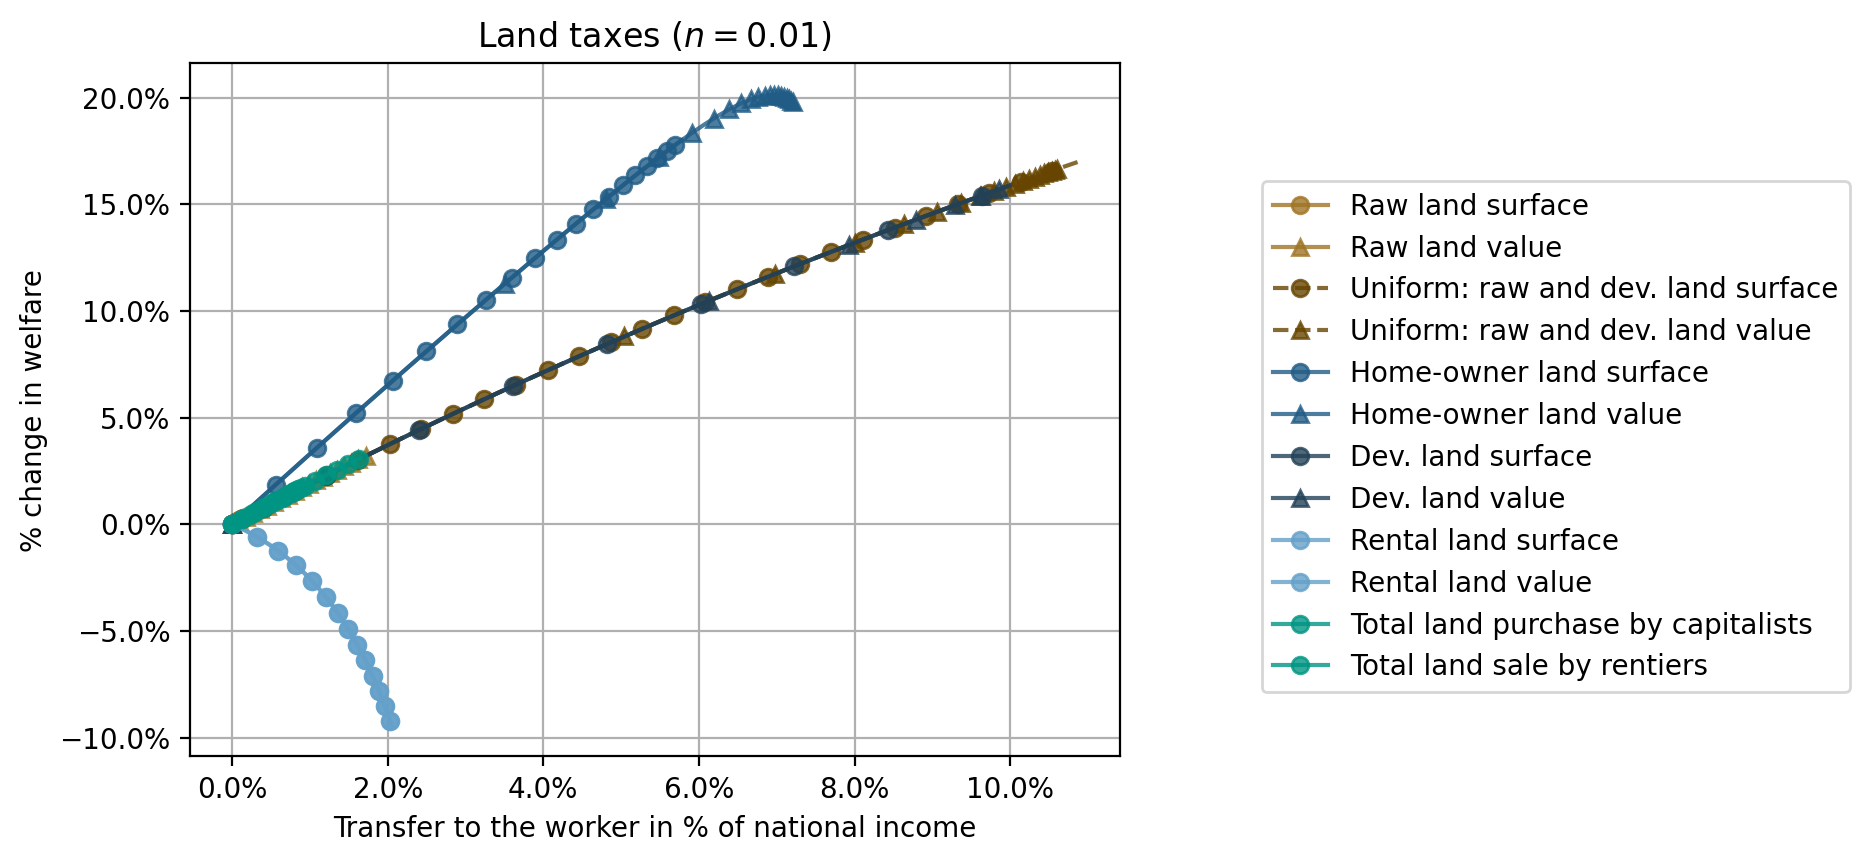

In [12]:

# ----------------------- Figure 8: taxes on land ------------------------

fig0, ax0 = plt.subplots(1,1, figsize=[6,4.5],dpi=200)


ax0.plot(df_LR_surface_cons['transfer %'], df_LR_surface_cons['welfare %'], linestyle='-', marker='o', color='#9F7526', 
         label='Raw land surface', alpha=0.8, markevery=10)
ax0.plot(df_LR_value_cons['transfer %'], df_LR_value_cons['welfare %'], linestyle='-', marker='^', color='#9F7526', 
         label='Raw land value', alpha=0.8, markevery=10)

ax0.plot(df_uniformL_surface_cons['transfer %'], df_uniformL_surface_cons['welfare %'], linestyle='--', marker='o', color='#674500', 
         label='Uniform: raw and dev. land surface', alpha=0.8, markevery=5)
ax0.plot(df_uniformL_value_cons['transfer %'], df_uniformL_value_cons['welfare %'], linestyle='--', marker='^', color='#674500', 
         label='Uniform: raw and dev. land value',alpha=0.8, markevery=10)

ax0.plot(df_L_surface_cons['transfer %'], df_L_surface_cons['welfare %'], linestyle='-', marker='o', color='#205c86', 
         label='Home-owner land surface', alpha=0.8, markevery=10)
ax0.plot(df_L_value_cons['transfer %'], df_L_value_cons['welfare %'], linestyle='-', marker='^', color='#205c86', 
         label='Home-owner land value', alpha=0.8, markevery=10)

ax0.plot(df_LDV_surface_cons['transfer %'], df_LDV_surface_cons['welfare %'], linestyle='-', marker='o', color='#224158', 
         label='Dev. land surface', alpha=0.8, markevery=15)
ax0.plot(df_LDV_value_cons['transfer %'], df_LDV_value_cons['welfare %'], linestyle='-', marker='^', color='#224158', 
         label='Dev. land value', alpha=0.8, markevery=15)

ax0.plot(df_l_surface_cons['transfer %'], df_l_surface_cons['welfare %'], linestyle='-', marker='o', color='#64a0c9', 
         label='Rental land surface', alpha=0.8, markevery=15)
ax0.plot(df_l_surface_cons['transfer %'], df_l_surface_cons['welfare %'], linestyle='-', marker='o', color='#64a0c9', 
         label='Rental land value', alpha=0.8, markevery=15)

ax0.plot(df_land_sale_cons['transfer %'], df_land_sale_cons['welfare %'], linestyle='-', marker='o', color='#009583', 
         label='Total land purchase by capitalists', alpha=0.8, markevery=15)
ax0.plot(df_land_purchase_cons['transfer %'], df_land_purchase_cons['welfare %'], linestyle='-', marker='o', color='#009583', 
         label='Total land sale by rentiers', alpha=0.8, markevery=15)

    

ax0.set_xlabel('Transfer to the worker in % of national income')
ax0.set_ylabel('% change in welfare')
ax0.set_title(f"Land taxes ($n={params_exog['n']}$)")
ax0.legend(ncol=1, loc='upper right', bbox_to_anchor=(1.8, 0.85))
ax0.grid()
ax0.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax0.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

fig.tight_layout()

if savefig==1:
    plt.savefig('Figures/Fig8_taxes_on_land_constrained.png', bbox_inches='tight')
plt.show()


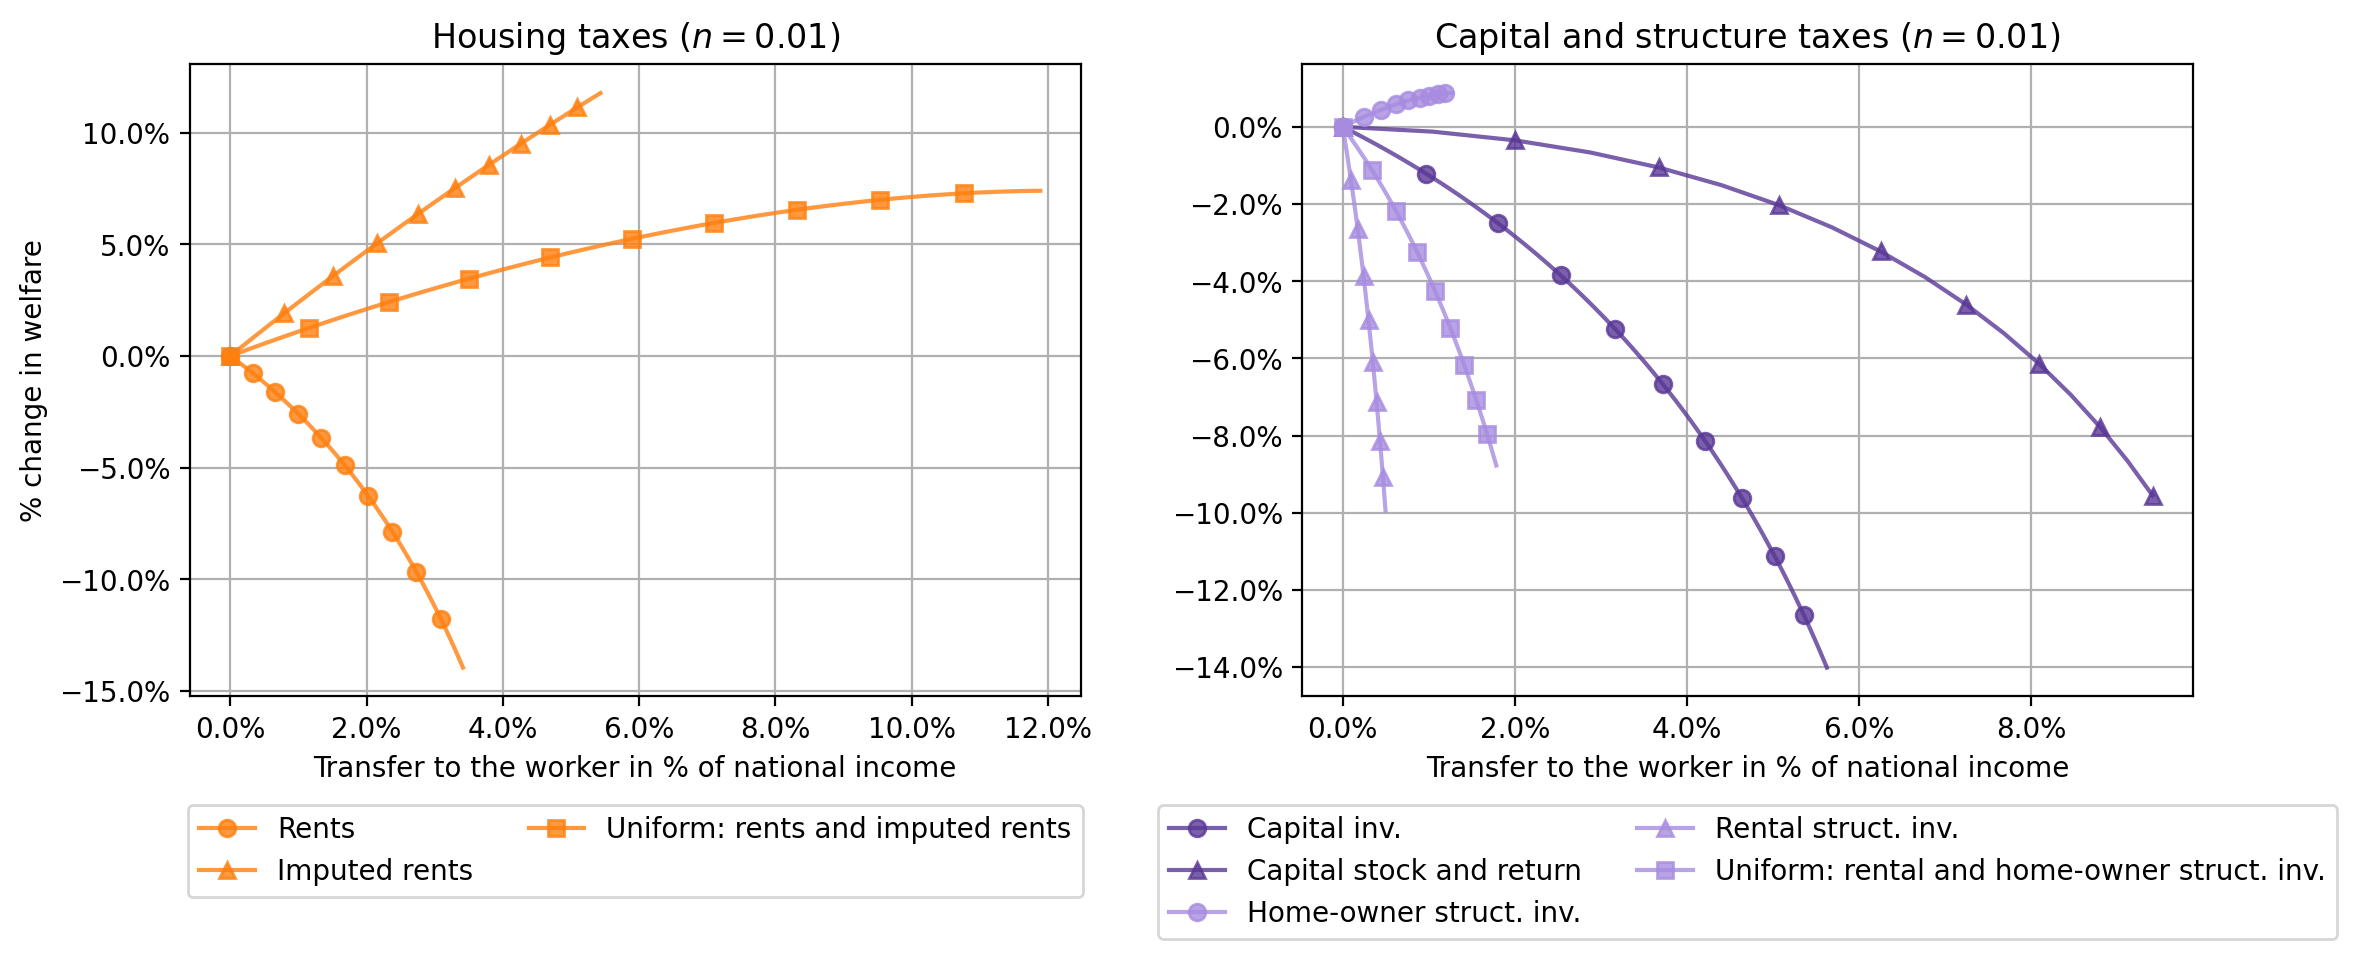

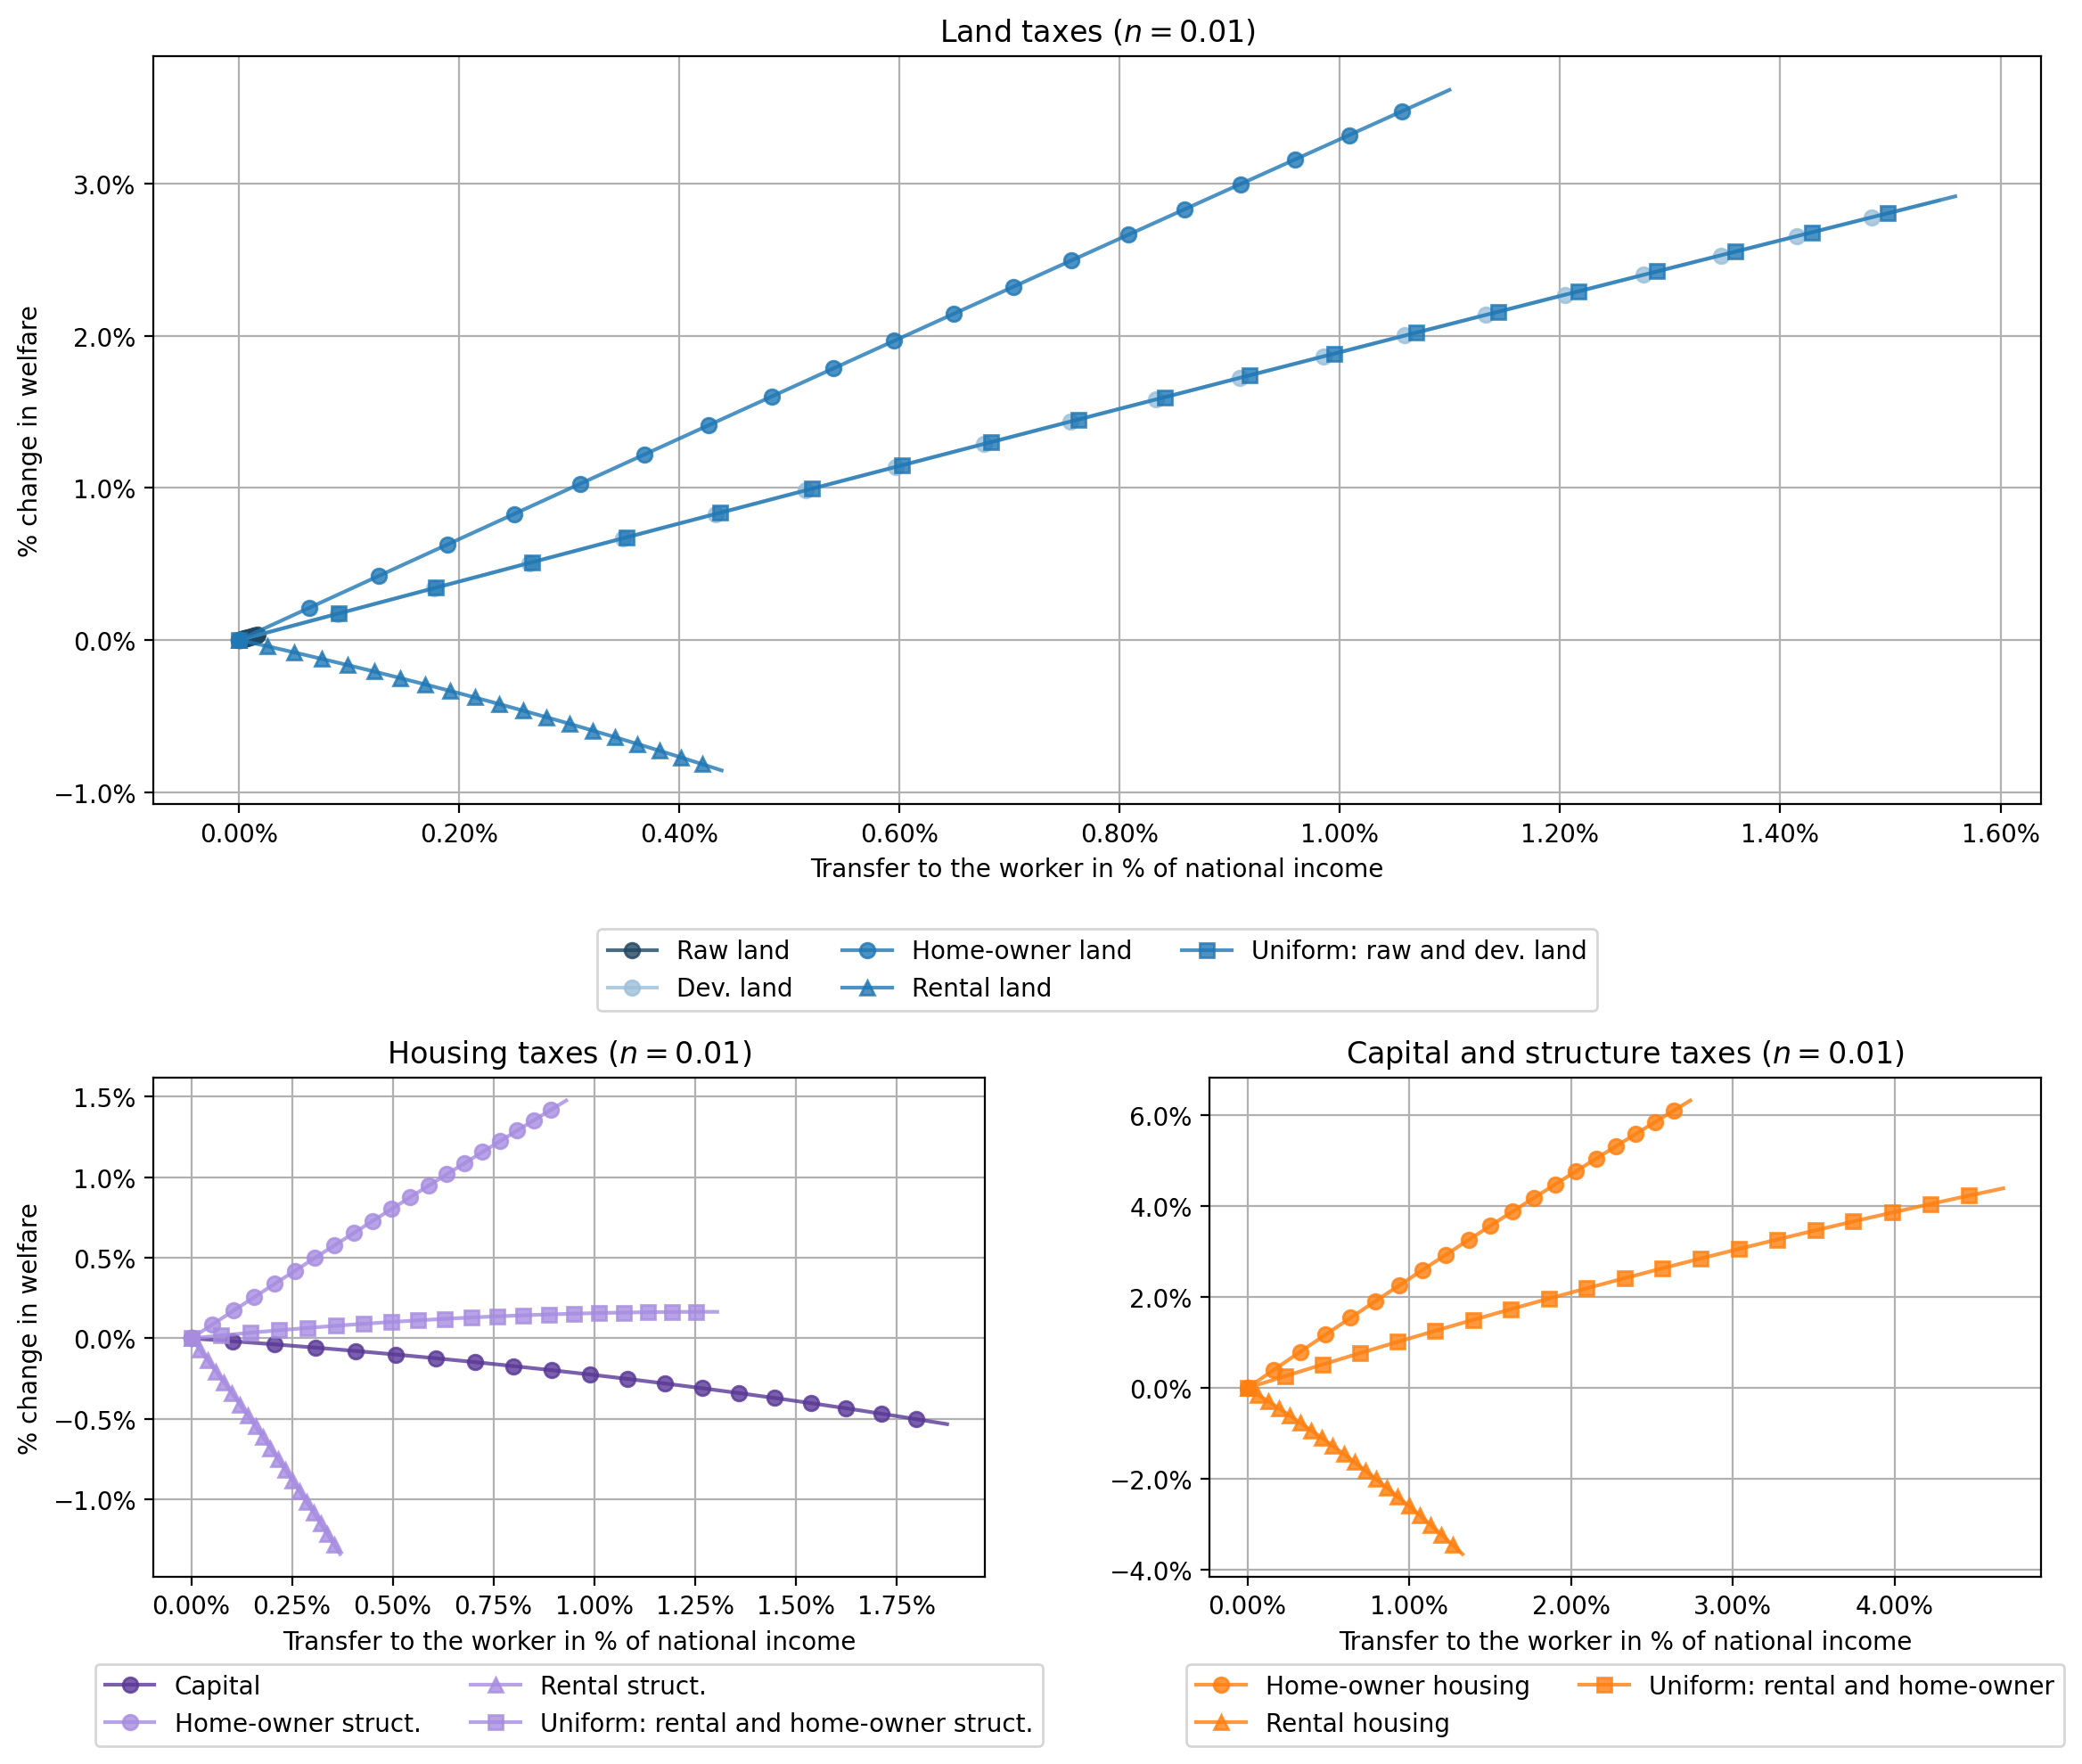

In [13]:

# ----------------------- Figure 9: taxes on housing, capital and structure ------------------------

# retreive all housing, capital, struct taxes
df_h_cons  = all_sol_cons['Rents'].query('sol_flag==0').query('tau_H <= 0.5')
df_H_cons    = all_sol_cons['Imputed rents'].query('sol_flag==0').query('tau_HI <= 0.5')
df_uniformHh_cons = all_sol_cons['Uniform: rents and imputed rents'].query('sol_flag==0').query('tau_H <= 0.5')

df_K_inv_cons   = all_sol_cons['Capital inv.'].query('sol_flag==0').query('tau_K_inv <= 0.5')
df_K_cons   = all_sol_cons['Capital stock and return'].query('sol_flag==0').query('tau_K <= 0.08')
df_S_cons     = all_sol_cons['Home-owner struct. inv.'].query('sol_flag==0').query('tau_S_inv <= 0.9')
df_s_cons   = all_sol_cons['Rental struct. inv.'].query('sol_flag==0').query('tau_s_inv <= 0.9')
df_uniformSs_cons     = all_sol_cons['Uniform: rental and home-owner struct. inv.'].query('sol_flag==0').query('tau_S_inv <= 0.9')





fig, ax1 = plt.subplots(1,2, figsize=[12,5], dpi=200)
ax1[0].plot(df_h_cons['transfer %'], df_h_cons['welfare %'], linestyle='-', marker='o', color='tab:orange', 
         label='Rents', alpha=0.8, markevery=10)
ax1[0].plot(df_H_cons['transfer %'], df_H_cons['welfare %'], linestyle='-', marker='^', color='tab:orange', 
         label='Imputed rents', alpha=0.8, markevery=10)
ax1[0].plot(df_uniformHh_cons['transfer %'], df_uniformHh_cons['welfare %'], linestyle='-', marker='s', color='tab:orange', 
         label='Uniform: rents and imputed rents', alpha=0.8, markevery=10)

ax1[1].plot(df_K_inv_cons['transfer %'], df_K_inv_cons['welfare %'], linestyle='-', marker='o', color='#593796', 
         label='Capital inv.', alpha=0.8, markevery=10)
ax1[1].plot(df_K_cons['transfer %'], df_K_cons['welfare %'], linestyle='-', marker='^', color='#593796', 
         label='Capital stock and return', alpha=0.8, markevery=2)

ax1[1].plot(df_S_cons['transfer %'], df_S_cons['welfare %'], linestyle='-', marker='o', color='#A78CE0', 
         label='Home-owner struct. inv.', alpha=0.8, markevery=20)
ax1[1].plot(df_s_cons['transfer %'], df_s_cons['welfare %'], linestyle='-', marker='^', color='#A78CE0', 
         label='Rental struct. inv.', alpha=0.8, markevery=20)
ax1[1].plot(df_uniformSs_cons['transfer %'], df_uniformSs_cons['welfare %'], linestyle='-', marker='s', color='#A78CE0', 
         label='Uniform: rental and home-owner struct. inv.', alpha=0.8, markevery=20)

ax1[0].set_xlabel('Transfer to the worker in % of national income')
ax1[0].set_ylabel('% change in welfare')
ax1[0].set_title(f"Housing taxes ($n={params_exog['n']}$)")
ax1[0].legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax1[0].grid()
ax1[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax1[1].set_xlabel('Transfer to the worker in % of national income')
# ax2.set_ylabel('% change in welfare')
ax1[1].set_title(f"Capital and structure taxes ($n={params_exog['n']}$)")
ax1[1].legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax1[1].grid()
ax1[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

fig.tight_layout()

if savefig==1:
    plt.savefig('Figures/Fig9_taxes_on_housing_KSs_constrained.png', bbox_inches='tight')
plt.show()



# ----------------------- Figure 10: all taxes on inheritance and bequests ------------------------

# land taxes
df_LR_DI_cons = all_sol_cons['DI_Raw land'].query('sol_flag==0')
df_uniformL_DI_cons    = all_sol_cons['DI_Uniform: raw and dev. land'].query('sol_flag==0')
df_LDV_DI_cons = all_sol_cons['DI_Dev. land'].query('sol_flag==0')
df_L_DI_cons = all_sol_cons['DI_Home-owner land'].query('sol_flag==0')
df_l_DI_cons   = all_sol_cons['DI_Rental land'].query('sol_flag==0')

# KSs taxes
df_K_DI_cons = all_sol_cons['DI_Capital'].query('sol_flag==0')
df_S_DI_cons    = all_sol_cons['DI_Home-owner struct.'].query('sol_flag==0')
df_s_DI_cons = all_sol_cons['DI_Rental struct.'].query('sol_flag==0')
df_uniformSs_DI_cons = all_sol_cons['DI_Uniform: rental and home-owner struct.'].query('sol_flag==0')

# housing taxes
df_H_DI_cons = all_sol_cons['DI_Home-owner housing'].query('sol_flag==0')
df_h_DI_cons   = all_sol_cons['DI_Rental housing'].query('sol_flag==0')
df_uniformHh_DI_cons = all_sol_cons['DI_Uniform: rental and home-owner'].query('sol_flag==0')


###################### create plot ######################

fig = plt.figure(figsize=[12, 10], dpi=200)
gs = GridSpec(nrows=2, ncols=2, height_ratios=[0.6, 0.4])
ax0 = fig.add_subplot(gs[0,:])
ax1 = fig.add_subplot(gs[1,0])
ax2= fig.add_subplot(gs[1,1])


# land taxes
ax0.plot(df_LR_DI_cons['transfer %'], df_LR_DI_cons['welfare %'], linestyle='-', marker='o', color='#214661', 
         label='Raw land', alpha=0.8, markevery=10)
ax0.plot(df_LDV_DI_cons['transfer %'], df_LDV_DI_cons['welfare %'], linestyle='-', marker='o', color='#9cc0da', 
         label='Dev. land', alpha=0.8, markevery=10)
ax0.plot(df_L_DI_cons['transfer %'], df_L_DI_cons['welfare %'], linestyle='-', marker='o', color='#1f77b4', 
         label='Home-owner land', alpha=0.8, markevery=10)
ax0.plot(df_l_DI_cons['transfer %'], df_l_DI_cons['welfare %'], linestyle='-', marker='^', color='#1f77b4', 
         label='Rental land', alpha=0.8, markevery=10)
ax0.plot(df_uniformL_DI_cons['transfer %'], df_uniformL_DI_cons['welfare %'], linestyle='-', marker='s', color='#1f77b4', 
         label='Uniform: raw and dev. land', alpha=0.8, markevery=10)

# capital structure taxes
ax1.plot(df_K_DI_cons['transfer %'], df_K_DI_cons['welfare %'], linestyle='-', marker='o', color='#593796', 
         label='Capital', alpha=0.8, markevery=10)
ax1.plot(df_S_DI_cons['transfer %'], df_S_DI_cons['welfare %'], linestyle='-', marker='o', color='#A78CE0', 
         label='Home-owner struct.', alpha=0.8, markevery=10)
ax1.plot(df_s_DI_cons['transfer %'], df_s_DI_cons['welfare %'], linestyle='-', marker='^', color='#A78CE0', 
         label='Rental struct.', alpha=0.8, markevery=10)
ax1.plot(df_uniformSs_DI_cons['transfer %'], df_uniformSs_DI_cons['welfare %'], linestyle='-', marker='s', color='#A78CE0', 
         label='Uniform: rental and home-owner struct.', alpha=0.8, markevery=10)

# housing taxes
ax2.plot(df_H_DI_cons['transfer %'], df_H_DI_cons['welfare %'], linestyle='-', marker='o', color='tab:orange', 
         label='Home-owner housing', alpha=0.8, markevery=10)
ax2.plot(df_h_DI_cons['transfer %'], df_h_DI_cons['welfare %'], linestyle='-', marker='^', color='tab:orange', 
         label='Rental housing', alpha=0.8, markevery=10)
ax2.plot(df_uniformHh_DI_cons['transfer %'], df_uniformHh_DI_cons['welfare %'], linestyle='-', marker='s', color='tab:orange', 
         label='Uniform: rental and home-owner', alpha=0.8, markevery=10)

ax0.set_xlabel('Transfer to the worker in % of national income')
ax0.set_ylabel('% change in welfare')
ax0.set_title(f"Land taxes ($n={params_exog['n']}$)")
ax0.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax0.grid()
ax0.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
ax0.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

ax1.set_xlabel('Transfer to the worker in % of national income')
ax1.set_ylabel('% change in welfare')
ax1.set_title(f"Housing taxes ($n={params_exog['n']}$)")
ax1.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax1.grid()
ax1.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

ax2.set_xlabel('Transfer to the worker in % of national income')
# ax2.set_ylabel('% change in welfare')
ax2.set_title(f"Capital and structure taxes ($n={params_exog['n']}$)")
ax2.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax2.grid()
ax2.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))

fig.tight_layout()

if savefig==1:
    plt.savefig('Figures/Fig10_taxes_DI_constrained.png', bbox_inches='tight')
plt.show()

In [ ]:

# ----------------------- Figure 11-12: heatmap over (rho, n)  ------------------------
n_grid = 200
n_arr = np.linspace(0.001, 0.014, n_grid)
rho_arr = np.linspace(0.001, 0.02, n_grid)

params_exog2var = params_exog.copy()
aleph = params_exog['aleph']

beta_arr = (1-aleph)/(1+rho_arr)

p_LR_matrix_cons = np.zeros([n_grid,n_grid])
p_LR_matrix_uncons = np.zeros([n_grid,n_grid])
R_K_gross_matrix_cons = np.zeros([n_grid,n_grid])
R_K_gross_matrix_uncons = np.zeros([n_grid,n_grid])

for i in range(n_grid):
    for j in range(n_grid):
        params_exog2var['n'] = n_arr[i]
        params_exog2var['beta'] = beta_arr[j]
        
        # print('n = ', n_arr[i], 'beta = ', beta_arr[j])
        
        sol_cons = solve_ss_constructible(params_exog2var, params_endog_cons, taxes_eq0, init_guess_cons)
        sol_uncons = solve_ss(params_exog2var, params_endog1, taxes_eq0, init_guess)
        
        p_LR_matrix_cons[i,j] = sol_cons['p_LR']
        p_LR_matrix_uncons[i,j] = sol_uncons['p_LR']
        R_K_gross_matrix_cons[i,j] = sol_cons['R_K_gross']
        R_K_gross_matrix_uncons[i,j] = sol_uncons['R_K_gross']

p_LR_over_RK_n_matrix_cons = np.zeros([n_grid, n_grid*n_grid])
p_LR_over_RK_n_matrix_uncons = np.zeros([n_grid, n_grid*n_grid])

R_K_arr_cons = np.sort(R_K_gross_matrix_cons.flatten())
R_K_arr_uncons = np.sort(R_K_gross_matrix_uncons.flatten())

for i in range(n_grid):
    for j in range(n_grid*n_grid):
        x = i
        
        try:
            y1 = np.where(R_K_gross_matrix_cons[i,:] == R_K_arr_cons[j])[0][0]
            y2 = np.where(R_K_gross_matrix_uncons[i,:] == R_K_arr_uncons[j])[0][0]
            
            p_LR_over_RK_n_matrix_cons[i,j] = p_LR_matrix_cons[x,y1]
            p_LR_over_RK_n_matrix_uncons[i,j] = p_LR_matrix_uncons[x,y2]
        except:
            pass

# plot
fig, ax = plt.subplots(1,2, figsize=[11,4], dpi=200)
pc = ax[0].pcolormesh(rho_arr, n_arr, p_LR_matrix_uncons, 
                    #  cmap='nipy_spectral', 
                  #  norm = mpl.colors.PowerNorm(gamma=1,
                  #                              vmin=0, vmax=34
                  #                              )
)
fig.colorbar(pc, ax=ax[0])

ax[0].set_xlabel(r'$\rho$')
ax[0].set_ylabel(r'$n$')
ax[0].set_title(r'$p^{\mathcal{L}_{R}}$, when land is unconstrained')
ax[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

pc2 = ax[1].pcolormesh(rho_arr, n_arr, p_LR_matrix_cons, 
                    #  cmap='nipy_spectral', 
                  #  norm = mpl.colors.PowerNorm(gamma=1,
                  #                              vmin=0, vmax=34
                  #                              )
)
fig.colorbar(pc2, ax=ax[1])

ax[1].set_xlabel(r'$\rho$')
ax[1].set_ylabel(r'$n$')
ax[1].set_title(r'$p^{\mathcal{L}_{R}}$, when land is constrained')
ax[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))


if savefig==1:
    plt.savefig('Figures/Fig11_pLR_over_n_rho.png', bbox_inches='tight')


# plot
fig, ax = plt.subplots(1,2, figsize=[11,4], dpi=200)
pc = ax[0].pcolormesh(rho_arr, n_arr, p_LR_matrix_uncons, 
                     cmap='nipy_spectral', 
                    norm = mpl.colors.PowerNorm(gamma=1,
                                               vmin=0, vmax=34
                                               )
)
fig.colorbar(pc, ax=ax[0])

ax[0].set_xlabel(r'$\rho$')
ax[0].set_ylabel(r'$n$')
ax[0].set_title(r'$p^{\mathcal{L}_{R}}$, when land is unconstrained')
ax[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

pc2 = ax[1].pcolormesh(rho_arr, n_arr, p_LR_matrix_cons, 
                     cmap='nipy_spectral', 
                   norm = mpl.colors.PowerNorm(gamma=1,
                                               vmin=0, vmax=34
                                               )
)
fig.colorbar(pc2, ax=ax[1])

ax[1].set_xlabel(r'$\rho$')
ax[1].set_ylabel(r'$n$')
ax[1].set_title(r'$p^{\mathcal{L}_{R}}$, when land is constrained')
ax[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

if savefig==1:
    plt.savefig('Figures/Fig12_pLR_over_n_rho_samecolscale.png', bbox_inches='tight')